<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.875 · Deep Learning · PEC3</p>
<p style="margin: 0; text-align:right;">2025-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 3: Transformers con PyTorch

A lo largo de esta práctica, implementaremos diversos modelos de análisis de sentimiento sobre la base de datos **GoEmotions**. En concreto, abordaremos las siguientes tareas:

<p>
En concreto, la práctica se estructura en las siguientes partes principales:
</p>
<ol>
  <li>Carga y preparación de datos (0.5 puntos)</li>
  <li>Análisis exploratorio del dataset (1.0 punto)</li>
  <li>Modelos basados en RNN (2.0 puntos)</li>
  <li>Modelos basados en atención (2.0 puntos)</li>
  <li>Modelos preentrenados (Hugging Face) (4.0 puntos)</li>
  <li>Conclusiones y reflexión final (0.5 puntos)</li>
</ol>


<u>Consideraciones generales</u>:

- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.
- Si se utiliza cualquier **IA generativa** en la resolución del PAC **se debe referenciar** en aquellas secciones donde se ha utilizado, como cualquier otra fuente.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.
- **Nota**: Servicios como Google Colab tienen un límite de uso de recursos que puede superarse cuando trabajamos con algunos de los modelos que vamos a ver en esta práctica. Para la entrega, los resultados deben estar visibles, pero no hace falta que se haya ejecutado todo el notebook en la misma sesión. Puede ejecutarse por apartados y las celdas de resultados se mantendránn visibles siempre que no vuelvan a ejecutarse.



---


# Contexto
<p>
En esta PEC implementaremos <strong>varios modelos de análisis de sentimiento</strong>, desde redes neuronales recurrentes simples hasta modelos tipo <em>Transformer</em> y modelos preentrenados de la plataforma <strong>Hugging Face</strong>, de la que hablaremos más en detalle en el último apartado.  
Para ello trabajaremos con la base de datos <strong><a href="https://github.com/google-research/google-research/tree/master/goemotions" target="_blank">GoEmotions</a></strong>, un conjunto de más de 58.000 comentarios de Reddit anotados con emociones. A diferencia de las PECs anteriores, aquí trabajaremos con <strong>texto</strong>, el dominio donde se aplicaron inicialmente los modelos <em>Transformer</em>.

<p>
A partir de esta práctica comenzaremos a utilizar <a href="https://pytorch.org/"><strong>PyTorch</strong></a> como plataforma principal para el desarrollo de modelos de <em>Deep Learning</em>. PyTorch se ha convertido en el <strong>framework más utilizado</strong> en investigación y en la industria para el desarrollo de modelos de Deep Learning y NLP. Por ejemplo, según el
<a href="https://www.stateof.ai/" target="_blank">State of AI Report</a>, más del <strong>70&nbsp;% de los modelos publicados en los últimos años</strong> se entrenan con PyTorch, y la mayoría de bibliotecas modernas de NLP (como <strong>Transformers</strong> de Hugging Face) están diseñadas principalmente para trabajar con él. Aprender PyTorch os dará la base necesaria para utilizar estas herramientas de última generación y facilitará la transición a proyectos de investigación o desarrollo profesional.
</p>

<p>
Para familiarizaros con PyTorch, podéis consultar los siguientes recursos recomendados:
<ul>
  <li><a href="https://pytorch.org/tutorials/" target="_blank">Tutoriales oficiales de PyTorch</a> (desde nivel principiante hasta avanzado).</li>
  <li><a href="https://lightning.ai/docs/pytorch/stable/" target="_blank">PyTorch Lightning</a> (opcional, para que lo conozcáis, pero en esta práctica usaremos PyTorch puro).</li>
  <li>Libros disponibles de forma gratuita a través de la <a href="https://biblioteca.uoc.edu">biblioteca de la UOC</a>:
    <ul>
      <li><em>Machine Learning with PyTorch and Scikit-Learn: Develop machine learning and deep learning models with Python</em>.</li>
      <li><em>PyTorch Recipes: A Problem-Solution Approach to Build, Train and Deploy Neural Network Models</em>.</li>
    </ul>
  </li>
</ul>
</p>

---



## Carga de librerías
A continuación se muestran las principales librerias necesarias para ejecutar esta PEC.

In [ ]:
'''Instalamos librerías necesarias para ejectar esta PEC:
- gensim: descarga de modelo GloVe para obtener embeddings de palabras.
'''
%pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.6 MB/s eta 0:00:00


In [ ]:
# Utilidades generales
import re
import random
from collections import Counter
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# NLP y procesamiento de texto
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

# Dataset GoEmotions de Hugging Face y librería transformer
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Descarga de embeddings GloVe preentrenados
import gensim.downloader as api

# PyTorch: modelo, entrenamiento y datos
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

# Evaluación
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Carga y preparación de datos (0.5 puntos)

---
A lo largo de esta práctica implementaremos distintos modelos de **análisis de sentimiento** utilizando la base de datos [GoEmotions](https://arxiv.org/pdf/2005.00547). **GoEmotions** es un conjunto de datos creado por Google que contiene más de **58 000 comentarios de Reddit** cuidadosamente anotados por humanos con etiquetas emocionales. El conjunto original incluye **27 emociones “finas” más una clase *neutral***, abarcando un amplio espectro de sentimientos y matices emocionales presentes en el lenguaje informal de internet.

Para simplificar el problema y facilitar la interpretación de resultados, en esta práctica trabajaremos con una **versión reducida** de GoEmotions, donde las emociones originales se han agrupado en **7 categorías principales propuestas por [Paul Ekman](https://es.wikipedia.org/wiki/Paul_Ekman)**:  
*anger*, *disgust*, *fear*, *joy*, *sadness*, *surprise* y *neutral*. Estas categorías representan emociones básicas universales y permiten analizar la carga emocional de los textos de forma más general, manteniendo un equilibrio entre complejidad y capacidad de interpretación.

Puedes consultar más información de esta base de datos en el [artículo original donde se describe](https://arxiv.org/abs/2005.00547) o en el [repositorio de Google Research donde está alojada](https://github.com/google-research/google-research/tree/master/goemotions).


---



<div style="background-color: #edf7ff; border-color: #7c9dbf; border-left: 5px solid #7c9dbf; padding: 0.5em;">

<p><strong>Ejercicio [0.5 pt]:</strong> En este primer apartado vamos a descargar y explorar la base de datos <strong>GoEmotions</strong>, preparándola para ser utilizada en los siguientes ejercicios.</p>

<p>En lugar de obtener el dataset directamente desde el repositorio original de Google Research, lo descargaremos desde la plataforma <strong><a href="https://huggingface.co/">Hugging Face</a></strong>. Esta plataforma ofrece una forma más sencilla y estandarizada de acceder a conjuntos de datos, permitiendo cargarlos con una sola línea de código y garantizando compatibilidad con librerías de procesamiento de lenguaje natural. Más adelante, en el último apartado de esta práctica, utilizaremos Hugging Face ampliamente para descargar modelos <em>Transformers</em> preentrenados que aplicaremos al análisis de sentimiento y clasificación sobre los datos de GoEmotions.</p>

<p>Para cargar los datos utilizaremos la función <code>load_dataset</code> del módulo <code>datasets</code> de Hugging Face. Esta función devuelve un objeto <code>DatasetDict</code> que contiene los diferentes <strong>splits</strong> del conjunto de datos (por ejemplo: <code>train</code>, <code>validation</code> y <code>test</code>). Cada uno de estos splits es un objeto <code>Dataset</code> que actúa como una tabla, donde cada fila corresponde a un ejemplo y cada columna es un campo (como <code>text</code> y <code>labels</code>, que contiene las emociones “finas” en formato de índices).</p>

<p>En esta primera parte realiza lo siguiente:</p>

<ol>
  <li>Descarga la base de datos <code>go_emotions</code> utilizando la librería <code>datasets</code> de Hugging Face.</li>
  <li>Muestra el <strong>número de instancias</strong> en cada uno de los conjuntos: <em>train</em>, <em>validation</em> y <em>test</em>.</li>
  <li>Muestra el <strong>número total de emociones “finas”</strong> (debería haber 28) y el nombre de las mismas.</li>
  <li> Calcula las <strong>emociones de Ekman</strong> a partir de las etiquetas “finas” incluidas en el dataset. Ten en cuenta que cada texto puede tener múltiples emociones finas, por lo que la función debe determinar cuál es la categoría de Ekman predominante. Para ello puedes utilizar la función <code>map_fine_to_ekman</code> que os proporcionamos más abajo para transformar el conjunto de datos original en uno que contenga únicamente los comentarios (atributo <code>text</code> del dataset), su categoría de Ekman en formato texto (atributo <code>class</code>) y la categoría en formato numérico (atributo <code>labels</code>). </li>
  <li>Para el conjunto de <em>train</em>, muestra por pantalla <strong>un ejemplo aleatorio (una fila del dataset)</strong> correspondiente a <strong>cada una de las categorías de Ekman</strong>.</li>
  <li>Genera un <strong>diagrama de barras</strong> que muestre el <strong>porcentaje de instancias</strong> de cada categoría de Ekman en los diferentes conjuntos: <em>train</em>, <em>validation</em> y <em>test</em>.</li>
</ol>

<p>A la vista de los resultados obtenidos en el punto 6 anterior, <strong>contesta además las siguientes preguntas</strong>:</p>
    <ul>
        <li>Según los diagramas de barras, ¿podemos afirmar que la distribución por clases es similar en los tres conjuntos?</li>
        <li>En cuanto al número de instancias (frases) por clase, ¿están las clases balanceadas o hay desequilibrios notables?</li>
    </ul>

<p>Se valorará la concisión en la respuesta a las preguntas (una o dos frases son suficientes para cada una de las respuestas).</p>
</div>



---


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
# Función proporcionada para transformar el dataset original de GoEmotions conteniendo emociones 'finas'
# a un dataset con emociones de Ekman
def map_fine_to_ekman(dataset):
    """
    Recibe el DatasetDict de go_emotions y devuelve un DatasetDict que solo contiene:
      - 'text': el texto original del comentario de Reddit.
      - 'class': categorías de Ekman en formato texto.
      - 'label': categoría de Ekman en formato numérico.
    """

    # Mapeo de emociones finas -> categorías de Ekman
    ekman2fine_mapping = {
        "anger": ["anger", "annoyance", "disapproval"],
        "disgust": ["disgust"],
        "fear": ["fear", "nervousness"],
        "joy": ["joy", "amusement", "approval", "excitement", "gratitude",
                "love", "optimism", "relief", "pride", "admiration", "desire", "caring"],
        "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
        "surprise": ["surprise", "realization", "confusion", "curiosity"],
        "neutral": ["neutral"],
    }

    # Mapeo de emociones Ekman a etiquetas numéricas (labels)
    ekman2label = {cat: i for i, cat in enumerate(sorted(ekman2fine_mapping.keys()))}

    # Invertir el mapeo para obtener fine_emotion -> ekman
    fine_to_ekman = {}
    for ekman_cat, fine_list in ekman2fine_mapping.items():
        for fine in fine_list:
            fine_to_ekman[fine] = ekman_cat

    # Lista completa de emociones finas del dataset
    fine_labels = dataset["train"].features["labels"].feature.names

    # Función auxiliar que convierte de emociones 'finas' a emociones de Ekman
    def convert(example):
      # Emociones finas presentes en el ejemplo
      fine_emos = [fine_labels[i] for i in example["labels"]]
      # Mapeo a Ekman (puede haber repeticiones)
      ekman_emos = [fine_to_ekman.get(e, "other") for e in fine_emos]
      # Contamos frecuencia por categoría Ekman
      counts = Counter(ekman_emos)
      if not counts:
          chosen = "other"
      else:
          # Escogemos como emoción de Ekman la más frecuente
          max_count = max(counts.values())
          candidatos = [emo for emo, c in counts.items() if c == max_count]
          # Si hay varias emociones igual de frecuentes, escogemos una aleatorimante
          chosen = random.choice(candidatos)
      return {"text": example["text"], 'class': chosen, 'labels': ekman2label[chosen]}

    # Aplicar a cada split (train, test, validation) y dejar solo 'text', 'label', y 'class'
    new_splits = {}
    for split_name, split_data in dataset.items():
        new_splits[split_name] = split_data.map(convert, remove_columns=split_data.column_names)

    return DatasetDict(new_splits)

In [ ]:
# Punto 1
# COMPLETAR: Cargar el dataset "go_emotions" de Hugging Face
dataset = load_dataset("go_emotions")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [ ]:
# Punto 2
# COMPLETAR: Mostrar número de instancias en cada split
print("Tamaño de cada partición:")
for split in dataset.keys():
    print(f"- {split}: {len(dataset[split])}")

Tamaño de cada partición:
- train: 43410
- validation: 5426
- test: 5427


In [ ]:
# Punto 3
# COMPLETAR: Muestra el número y tipo de emociones "finas" en el dataset
fine_labels = dataset["train"].features["labels"].feature.names
print("Número de emociones finas:", len(fine_labels))
print("Emociones finas:", fine_labels)

Número de emociones finas: 28
Emociones finas: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [ ]:
# Punto 4
# COMPLETAR: Obtener un dataset con las emociones de Ekman
ds_ekman = map_fine_to_ekman(dataset)
print(f'Dataset: {ds_ekman}')

# Mostramos algunas filas de la tabla
print(f'Fila 0: {ds_ekman["train"][0]}')
print(f'Fila 1: {ds_ekman["train"][1]}')
print(f'Última fila: {ds_ekman["train"][-1]}')

Dataset: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'class'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'class'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'class'],
        num_rows: 5427
    })
})
Fila 0: {'text': "My favourite food is anything I didn't have to cook myself.", 'labels': 4, 'class': 'neutral'}
Fila 1: {'text': 'Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead', 'labels': 4, 'class': 'neutral'}
Última fila: {'text': 'Enjoy the ride!', 'labels': 3, 'class': 'joy'}


In [ ]:
# Punto 5
# COMPLETAR: Mostrar un ejemplo (comentario) aleatorio del conjunto de "train"
# para cada categoría de Ekman

ekman_labels = sorted(set(ds_ekman["train"]["class"]))
print("Categorías de Ekman:", ekman_labels)
print("Número de categorías:", len(ekman_labels))

print("")
print("Ejemplo aleatorio por categoría:")
for cat in ekman_labels:
    # Filtrar los comentarios que pertenecen a la categoría 'cat'
    filtered_ds = ds_ekman['train'].filter(lambda example: example["class"] == cat)
    if filtered_ds.num_rows == 0:
        continue
    # Elegir un comentario al azar
    i = np.random.randint(len(filtered_ds))
    example = filtered_ds[i]
    print(f'{cat.upper():<10}: {example["text"]}')

Categorías de Ekman: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
Número de categorías: 7

Ejemplo aleatorio por categoría:
ANGER     : you are delucional.
DISGUST   : yea so disgusting
FEAR      : Tear all of it down - that place is such a horrific example of trash civil engineering
JOY       : *Hey just noticed..* it's your **5th Cakeday** melodesign! ^(hug)
NEUTRAL   : If you stick a pinky in your butt it activates the hippo camping with us part of your brain.
SADNESS   : sorry should clarify ... have dinner / drinks and then go our separate ways to other events that night.
SURPRISE  : Is it weird that my first thought was "at least it's not a Minion?" 


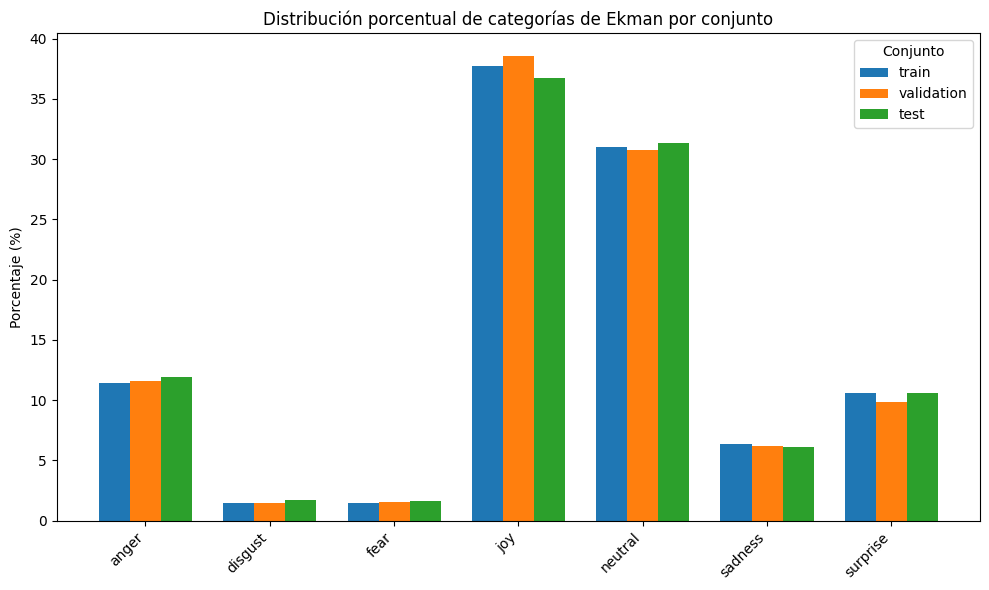

In [ ]:
# Punto 6
# COMPLETAR: Crea un gráfico de barras con el porcentaje de instancias en cada
# categoría de Ekman para los 3 conjuntos: 'train', 'validation' y 'test'

# Contamos la frecuencia de cada categoría de Ekman en cada partición. Para ello,
# creamos un diccionario 'split' => lista con las frecuenciadas de cada categoría Ekman

# a) Diccionario de frecuencias
ekman_freqs_per_split = {split: [] for split in ds_ekman.keys()}

for split in ds_ekman.keys():
    class_in_split = ds_ekman[split]["class"]
    total = len(class_in_split)
    counter = Counter(class_in_split)
    for cat in ekman_labels:
        ekman_freqs_per_split[split].append(counter.get(cat, 0) * 100.0 / total)

# b) Graficar
x = range(len(ekman_labels))
width = 0.25  # ancho de cada barra

plt.figure(figsize=(10, 6))

for i, split in enumerate(ds_ekman.keys()):
    plt.bar(
        [p + i * width for p in x],
        ekman_freqs_per_split[split],
        width=width,
        label=split)

plt.xticks([p + width for p in x], ekman_labels, rotation=45, ha="right")
plt.ylabel("Porcentaje (%)")
plt.title("Distribución porcentual de categorías de Ekman por conjunto")
plt.legend(title="Conjunto")
plt.tight_layout()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>RESPUESTA A LAS PREGUNTAS:</strong></p>
<ul>
  <li><strong>Según los diagramas de barras, ¿podemos afirmar que la distribución por clases es similar en los tres conjuntos?</strong>
    <p>Efectivamente, el diagrama de barras muestra que no hay diferencias notables entre las categorías de Ekman en los tres conjuntos; la distribución es bastante similar en <em>train</em>, <em>validation</em> y <em>test</em>.</p>
  </li>
  <li><strong>En cuanto al número de instancias (frases) por clase, ¿están las clases balanceadas o hay desequilibrios notables?</strong>
    <p>Es un dataset muy desbalanceado: domina claramente la clase “joy” (~37.5% de las instancias) y luego “neutral” (~30%). Después aparecen “anger” y “surprise”, con alrededor del 10% cada una. Las clases menos representadas son “disgust” y “fear”, con alrededor del 2.5% de las instancias cada una.</p>
  </li>
</ul>  
</div>

# 2. Análisis exploratorio del dataset (1 punto)


---



En este apartado realizaremos un análisis preliminar para comprender mejor el contenido del dataset y cómo se distribuyen las emociones antes de pasar a modelos más avanzados.
Se trabajará con tres técnicas clásicas de procesamiento de lenguaje natural (NLP) que permiten analizar y visualizar el conjunto de datos de forma intuitiva:

<ul>
  <li><strong>1. Extracción de palabras representativas con TF-IDF:</strong>  
    En primer lugar, caracterizaremos cada emoción buscando sus <strong>5 palabras más representativas</strong>.  
    Para ello usaremos la técnica <a href="https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/">TF-IDF</a> (<em>Term Frequency – Inverse Document Frequency</em>), un método clásico de NLP que asigna un peso alto a las palabras que aparecen con frecuencia en una clase concreta pero son poco frecuentes en el resto del corpus. De esta manera podemos identificar términos distintivos para cada emoción.
  </li>

  <li><strong>2. Representación de frases mediante embeddings de palabras (GloVe):</strong>  
    Posteriormente, para construir una representación numérica de las frases incluidas en la base de datos GoEmotions, realizaremos un paso común en muchos métodos de NLP: transformar las palabras en <strong>vectores densos</strong> (<em>embeddings</em>).  
    A diferencia de las técnicas de tokenización y embeddings contextualizados que estudiaremos más adelante con modelos <strong>Transformers</strong>, aquí emplearemos un método clásico: <a href="https://nlp.stanford.edu/projects/glove/">GloVe</a> (<em>Global Vectors for Word Representation</em>).  
    GloVe genera embeddings de palabras aprendiendo patrones de coocurrencia en un gran corpus de texto, de manera que palabras que aparecen en contextos similares tienen representaciones vectoriales cercanas.
  </li>

  <li><strong>3. Visualización de patrones emocionales con t-SNE:</strong>  
    Finalmente, realizaremos un análisis exploratorio visual proyectando los <strong>embeddings de cada frase</strong> (calculados promediando los embeddings de todas sus palabras) a un espacio bidimensional usando la técnica <a href="https://www.datacamp.com/tutorial/introduction-t-sne">t-SNE</a> (<em>t-distributed Stochastic Neighbor Embedding</em>).  
    t-SNE es un algoritmo de reducción de dimensionalidad que permite representar datos de alta dimensión en 2D preservando relaciones de cercanía. Esto nos permitirá visualizar cada comentario de GoEmotions como un punto en el plano, coloreado según su categoría de emoción, para observar si se forman agrupamientos entre puntos de la misma clase y explorar qué emociones aparecen más próximas entre sí.
  </li>
</ul>


---


<div style="background-color: #edf7ff; border-color: #7c9dbf; border-left: 5px solid #7c9dbf; padding: 0.5em;">

<p><strong>Ejercicio [1 pt]:</strong> Realiza los siguientes análisis:

<ol>
  <li>
    <strong>Calcula y muestra las 5 palabras más representativas de cada categoría de Ekman en el conjuto de <code>train</code> usando TF-IDF</strong>.  
<p> Para ello, primero transforma el texto de cada comentario (fila del dataset) en una matriz TF-IDF (una fila = un comentario, una columna = una palabra) usando la clase <code>TfidfVectorizer</code> de <code>scikit-learn</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html" target="_blank">documentación</a>). Puedes acceder a la lista de comentarios del dataset de HuggingFace a través de la propiedad <code>"text"</code>. Luego, para cada categoría de Ekman, selecciona los comentarios de esa clase, calcula la media por columnas (por palabras) de la matriz TF-IDF, ordena los términos según el valor TF-IDF de la tabla y muestra las 5 palabras con mayor <em>score</em> TF-IDF para cada emoción.</p>

<p>Para completar este ejercicio, puedes revisas la ayuda de <code>TfidfVectorizer</code> y los tutoriales oficiales de scikit-learn. En particular, este ejemplo de extracción de temas con NMF/LDA (donde se utiliza <code>TfidfVectorizer</code>) puede servirte de guía para construir y explorar la matriz TF-IDF:  
<a href="https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html#sphx-glr-auto-examples-applications-plot-topics-extraction-with-nmf-lda-py" target="_blank">
https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html#sphx-glr-auto-examples-applications-plot-topics-extraction-with-nmf-lda-py
</a> </p>

  </li>

  <li>
  <strong>Representa cada comentario del conjunto de <code>validation</code> como un vector denso (embedding) utilizando un modelo preentrenado <strong>GloVe</strong></strong>.  
Para ello, primero deberás <strong>tokenizar</strong> los comentarios, es decir, dividir cada texto en palabras individuales.  
Puedes utilizar para ello la función <code>tokenize</code> que se proporciona como ejemplo más abajo, o implementar tu propio tokenizador sencillo que elimine signos de puntuación y pase las palabras a minúsculas.

A continuación, descarga un modelo GloVe preentrenado (por ejemplo, <code>glove-wiki-gigaword-50</code>) disponible a través de <code>gensim.downloader</code>
(<a href="https://radimrehurek.com/gensim/downloader.html" target="_blank">documentación</a>,
<a href="https://nlp.stanford.edu/pubs/glove.pdf" target="_blank">paper original</a>) y obtén el <em>embedding</em> de cada palabra presente en los comentarios.

Después, combina los vectores de todas las palabras de cada comentario para generar un único embedding de frase. La forma más sencilla es calcular el <strong>promedio de los embeddings</strong> de las palabras de cada comentario.
  </li>

  <li>
    <strong>Proyecta los embeddings de frases del conjunto de <code>validation</code> a 2 dimensiones con t-SNE</strong>
    (<a href="https://lvdmaaten.github.io/tsne/" target="_blank">paper</a>,
    <a href="https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html" target="_blank">implementación en scikit-learn</a>, <a href="https://www.kaggle.com/code/venkatkrishnan/t-sne-decomposition-on-mnist-dataset">tutorial para MNIST</a>). Para ello, genera un <strong>gráfico 2D</strong> donde cada punto represente una frase y su color indique la categoría de Ekman correspondiente.
  </li>
</ol>

<p>A partir de los resultados obtenidos, <strong>responde a las siguientes preguntas de análisis:</strong></p>
<ul>
    <li>
        ¿Cuáles son las <strong>palabras más representativas</strong> para la categoría <em>disgust</em>? ¿Y cuáles destacan como más relevantes para la categoría <em>joy</em>?
    </li>
    <li>
        Observa el <strong>gráfico 2D</strong> obtenido mediante la técnica <strong>t-SNE</strong>.
        ¿Se aprecian agrupamientos claros entre las distintas emociones o existe un solapamiento significativo entre clases?
        Además, ¿qué estrategias propondrías para <strong>mejorar el cálculo de los embeddings de frase</strong> y así obtener una representación más separable entre categorías de emoción?
    </li>
</ul>
</div>


---



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
# Tokenizador de ejemplo:
# -----------------------
# 1. Definimos una expresión regular (TOKEN_RE) que busca secuencias de caracteres "de palabra"
#    (\w = letras, números y guiones bajos) delimitadas por límites de palabra (\b).
#    El flag re.UNICODE permite que se reconozcan caracteres Unicode (acentos, ñ, etc.).
#
# 2. La función tokenize(text) aplica esa expresión regular a un texto:
#    - TOKEN_RE.findall(text) devuelve una lista con todas las "palabras" encontradas
#      (ignorando signos de puntuación y espacios).
#    - Luego convertimos cada palabra a minúsculas con .lower().
#
# Ejemplo:
# >>> tokenize("¡Hola, mundo!")
# ['hola', 'mundo']
#
TOKEN_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)

def tokenize(text):
    return [t.lower() for t in TOKEN_RE.findall(text)]

In [ ]:
# Punto 1
# COMPLETAR: Calcula las 5 palabras más representativas de cada emoción de Ekman
# a partir de sus comentarios en el conjunto de 'train'

# --- 1. Creamos un vectorizador TF-IDF ---
# min_df=5 para ignorar palabras muy raras
vectorizer = TfidfVectorizer(stop_words='english', min_df=5)
X_tfidf = vectorizer.fit_transform(ds_ekman["train"]["text"])
feature_names = vectorizer.get_feature_names_out()

# --- 2. Para cada clase calculamos las palabras con mayor TF-IDF medio ---
top_words_per_class = {}
for cls in sorted(ekman_labels):
    # índices de las filas que pertenecen a esta clase
    idx = [i for i, lab in enumerate(ds_ekman['train']['class']) if lab == cls]
    if not idx:
        continue

    # Submatriz con solo los ejemplos de esa clase
    X_cls = X_tfidf[idx]

    # Media de TF-IDF por palabra dentro de la clase
    mean_tfidf = X_cls.mean(axis=0).A1  # convertimos a vector plano

    # Seleccionamos las 5 palabras con mayor media
    top_indices = mean_tfidf.argsort()[-5:][::-1]
    top_words = [feature_names[i] for i in top_indices]

    top_words_per_class[cls] = top_words

# --- 3. Mostramos resultados ---
for cls, words in top_words_per_class.items():
    print(f"{cls.upper():<10}: {', '.join(words)}")

ANGER     : don, fuck, like, just, hate
DISGUST   : disgusting, awful, worst, weird, worse
FEAR      : scared, afraid, terrible, scary, worried
JOY       : love, thanks, thank, good, lol
NEUTRAL   : just, like, don, people, think
SADNESS   : sorry, sad, bad, just, feel
SURPRISE  : know, did, just, don, oh


In [ ]:
# Punto 2
# COMPLETAR: Obtén las embeddings por frase para cada comentario del conjunto de
# 'validation' promediando los embeddings de palabras obtenidos con el modelo
# 'glove-wiki-gigaword-50'

# -------------------------------------------------------
# 1. Cargar modelo GloVe preentrenado glove-wiki-gigaword-50
#    Puedes usar otros tamaños: glove-wiki-gigaword-50/100/200/300
# -------------------------------------------------------
print("Descargando/cargando GloVe (puede tardar la primera vez)...")
glove50 = api.load("glove-wiki-gigaword-50")
print("GloVe cargado correctamente.")

Descargando/cargando GloVe (puede tardar la primera vez)...
GloVe cargado correctamente.


In [ ]:
# Punto 2b

# -------------------------------------------------------
# 2. Función para calcular el embedding promedio de una frase
# -------------------------------------------------------
def sentence_embedding_avg(text, glove_model):
    tokens = tokenize(text)
    vecs = [glove_model.get_vector(tok) for tok in tokens if tok in glove_model]
    if not vecs:
        # Si no hay palabras con embedding, devolvemos un vector cero
        return np.zeros(glove_model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)

# -------------------------------------------------------
# 5. Generar los embeddings para todas las frases
# -------------------------------------------------------
embeddings = np.vstack([sentence_embedding_avg(comentario, glove50) for comentario in ds_ekman['validation']['text']])
print("Embeddings generados con forma:", embeddings.shape)

Embeddings generados con forma: (5426, 50)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5426 samples in 0.001s...
[t-SNE] Computed neighbors for 5426 samples in 0.523s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5426
[t-SNE] Computed conditional probabilities for sample 2000 / 5426
[t-SNE] Computed conditional probabilities for sample 3000 / 5426
[t-SNE] Computed conditional probabilities for sample 4000 / 5426
[t-SNE] Computed conditional probabilities for sample 5000 / 5426
[t-SNE] Computed conditional probabilities for sample 5426 / 5426
[t-SNE] Mean sigma: 0.010903
[t-SNE] Computed conditional probabilities in 0.171s
[t-SNE] Iteration 50: error = 86.2528687, gradient norm = 0.0004458 (50 iterations in 2.698s)
[t-SNE] Iteration 100: error = 85.7956314, gradient norm = 0.0016863 (50 iterations in 2.538s)
[t-SNE] Iteration 150: error = 85.6514816, gradient norm = 0.0000932 (50 iterations in 2.058s)
[t-SNE] Iteration 200: error = 85.6527786, gradient norm = 0.0001134 (50 iterations in 1.824s)
[t

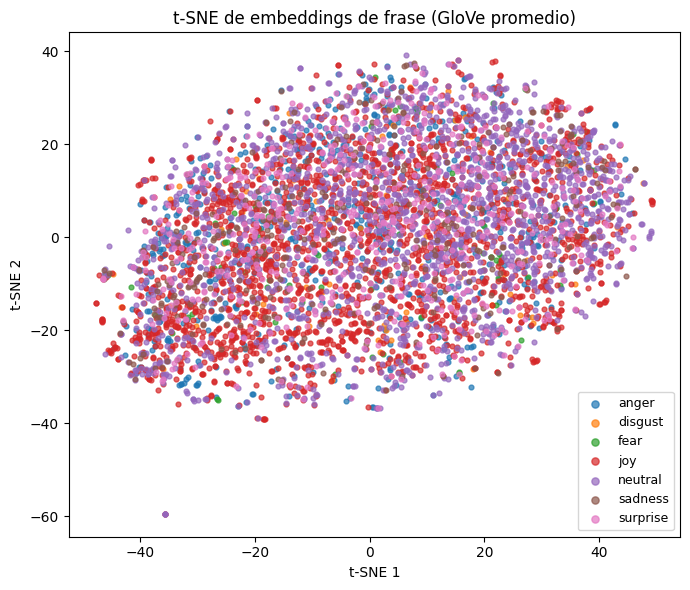

In [ ]:
# Punto 3: Visualización de los embeddings en 2D con t-SNE
# COMPLETAR: Usa la técnica t-SNE para proyectar y visualizar en un espacio 2D los embeddings
# por frase obtenidos en el punto anterior para el conjunto de 'validation'

labels = np.array(ds_ekman['validation']['labels'])

# -------------------------------------------------------
# 1) t-SNE a 2D
#    - metric='cosine' suele ir bien con embeddings
#    - init='pca' ayuda a la estabilidad
#    - ajusta perplexity según el tamaño del dataset (10–50)
# -------------------------------------------------------
tsne = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42,
    verbose=4,
    n_jobs=-1
)
X_2d = tsne.fit_transform(embeddings)

# -------------------------------------------------------
# 2) Gráfico 2D coloreado por clase
# -------------------------------------------------------
plt.figure(figsize=(7, 6))
for i, cls in enumerate(sorted(ekman_labels)):
    mask = (labels == i)
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=12,
        alpha=0.7,
        label=cls
    )

plt.title("t-SNE de embeddings de frase (GloVe promedio)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(markerscale=1.5, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>RESPUESTA A LAS PREGUNTAS:</strong></p>
<ul>
    <li>
        <strong>¿Cuáles son las palabras más representativas para la categoría <em>disgust</em>? ¿Y cuáles destacan como más relevantes para la categoría <em>joy</em>?</strong>
        <p>
            Para la emoción <strong>disgust</strong> destacan especialmente las palabras:
            <code>disgusting</code>, <code>awful</code>, <code>worst</code>, <code>worse</code> y <code>weird</code>.  
            En el caso de la emoción <strong>joy</strong>, las más representativas son:
            <code>love</code>, <code>thanks</code>, <code>thank</code>, <code>good</code> y <code>lol</code>.
        </p>
    </li>
    <li>
        <strong>Observa el gráfico 2D obtenido mediante la técnica t-SNE.
        ¿Se aprecian agrupamientos claros entre las distintas emociones o existe un solapamiento significativo entre clases?  
        Además, ¿qué estrategias propondrías para mejorar el cálculo de los embeddings de frase y así obtener una representación más separable entre categorías de emoción?</strong>
        <p>
            En el gráfico se observa un <strong>alto solapamiento entre las clases</strong>, sin que se formen agrupamientos claramente diferenciados para las distintas emociones.  
            Esto ocurre porque el cálculo de los embeddings de frase se ha hecho simplemente <strong>promediando los vectores de las palabras</strong>, sin tener en cuenta la relevancia de cada término ni el hecho de que muchas palabras frecuentes (como determinantes, preposiciones o verbos muy comunes) aparecen en cualquier emoción.  
            Una posible mejora sería <strong>ponderar cada palabra según su relevancia</strong> dentro de la clase, por ejemplo usando los pesos obtenidos con TF-IDF, y así reducir la influencia de palabras muy frecuentes pero poco informativas a la hora de calcular los <em>embeddings por frase</em>. También podría ayudar experimentar con modelos de embeddings más avanzados (como representaciones de oraciones basadas en Transformers) para obtener una separación más clara entre categorías. Esto se estudiará en la próximas secciones.
        </p>
    </li>
</ul>
</div>

# 3. Modelos basados en RNN (2 puntos)


<div style="background-color: #edf7ff; border-color: #7c9dbf; border-left: 5px solid #7c9dbf; padding: 0.5em;">

---



<strong>Ejercicio [2 pts.]:</strong>  Como continuación del trabajo que realizasteis en la PEC anterior, en este ejercicio vamos a implementar un  
<strong>modelo de análisis de sentimiento</strong> sencillo basado en una <strong>red neuronal recurrente unidireccional</strong>, utilizando la base de datos <strong>GoEmotions</strong> ya simplificada a las 7 emociones de Ekman. En este primer modelo reutilizaremos la <strong>función de tokenización</strong> (<code>tokenize</code>) implementada en el ejercicio anterior para dividir los comentarios en palabras, así como los <strong>embeddings preentrenados de GloVe</strong> para convertir cada palabra en un vector denso que capture su significado semántico.</p>

<p>La arquitectura que implementaremos será una <strong>GRU unidireccional</strong> como la que se muestra en el siguiente diagrama. En primer lugar, tal y como se hizo en el ejercicio anterior, se usará la función <code>tokenize</code> para dividir cada comentario en una lista de palabras [w<sub>1</sub>, w<sub>2</sub>, ..., w<sub>N</sub>] y estas, a su vez, se mapearán a una secuencia de embeddings con el modelo GloVe <code>glove-wiki-gigaword-50</code>. Estos vectores densos serán las entradas de la GRU, generando ésta un estado oculto para cada token de entrada (palabra). Finalmente, se tomará únicamente el <strong>estado oculto correspondiente a la última palabra</strong> h<sub>N</sub> como representación de toda la frase, y este vector se conectará a una <strong>capa densa con activación <em>softmax</em></strong> que clasificará el comentario en una de las 7 emociones de Ekman.</p>

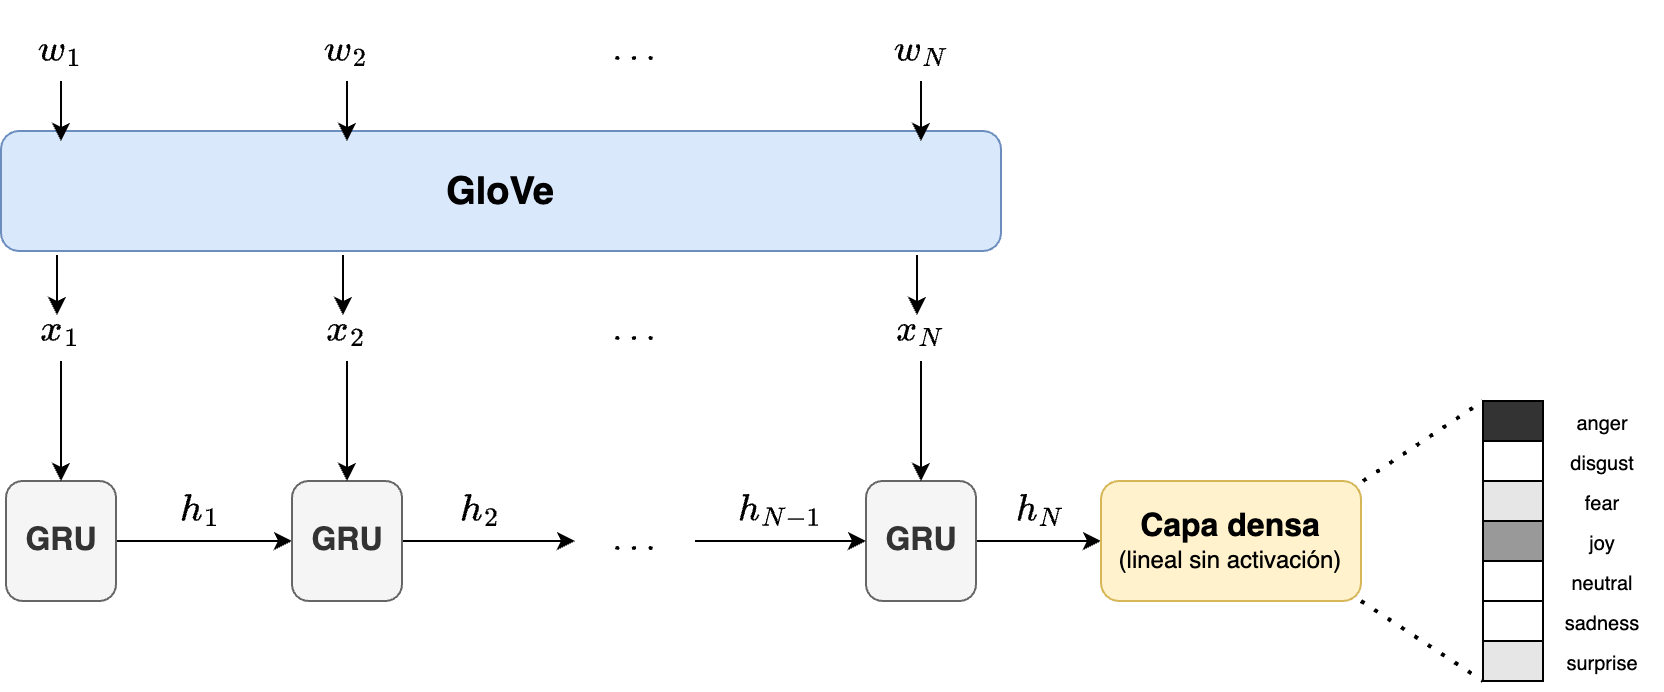

<p>Para implementar este modelo, sigue los siguientes pasos:</p>

<ol>
<li>
  <strong>Creación de los <code>DataLoader</code></strong>.
  <p>
    Antes de entrenar la red <strong>GRU</strong>, necesitamos preparar cómo se enviarán los datos al modelo.  En PyTorch esto se hace con dos componentes clave:
  </p>

  <ul>
    <li>
      <strong><code>Dataset</code></strong>: representa el conjunto de datos y define cómo acceder a cada ejemplo individual. Dado un índice, devuelve el texto y su etiqueta correspondiente. Usaremos el dataset de Hugging Face (campos <code>text</code> y <code>label</code>).
    </li>
    <li>
      <strong><code>DataLoader</code></strong>: recibe un <code>Dataset</code> y se encarga de agrupar ejemplos en <strong>batches</strong>, barajarlos y prepararlos para el entrenamiento eficiente en CPU o GPU.
    </li>
  </ul>

  <p>
    Tu tarea será crear un <code>DataLoader</code> para cada conjunto de datos (<code>train</code>, <code>validation</code>, <code>test</code>)
    y utilizar la función <strong><code>collate_fn</code></strong> personalizada que procese cada lote. En esta práctica la función <strong><code>collate_fn</code></strong> os la proporcionamos, pero recomendamos entender cómo funciona internamente, ya que cuando trabajéis en vuestros propios proyectos a futuro lo necesitaréis:
  </p>

  <ul>
    <li>Accede a los campos <code>text</code> y <code>label</code> de los ejemplos del batch.</li>
    <li>Tokeniza cada comentario (usa la función <code>tokenize</code> proporcionada anteriormente).</li>
    <li>Conveierte cada token a su vector <strong>GloVe</strong> (un embedding por palabra).</li>
    <li>
      Aplica <strong>padding dinámico</strong> para que todas las secuencias del batch tengan la misma longitud (la de la frase más larga en ese batch).
    </li>
    <li>
      Devuelve tres tensores de PyTorch:
      <ul>
        <li><code>sent_embeddings</code> — tensor <code>[B, T, E]</code> con los embeddings GloVe y padding de ceros para todas los comentarios del batch.</li>
        <li><code>lengths</code> — tensor <code>[B]</code> con la longitud real de cada secuencia antes del padding.</li>
        <li><code>labels</code> — tensor <code>[B]</code> con las etiquetas enteras (emociones) de cada comentarios.</li>
      </ul>
    </li>
  </ul>

</li>


  <li>
    <strong>Definición del modelo GRU</strong>.  
    <p>Crea una clase en <strong>PyTorch</strong> que implemente una <strong>GRU unidireccional de una sola capa</strong>, como la representada en el diagrama anterior. Esta clase debe <strong>heredar de <code>torch.nn.Module</code></strong> y definir dos métodos:</p>
<ul>
  <li><code>__init__</code>: donde se construye la arquitectura (una capa <strong>GRU</strong> que recibe los <em>embeddings</em> GloVe y una capa totalmente conectada para la clasificación final).</li>
  <li><code>forward</code>: recibe los lotes del <code>DataLoader</code> —el tensor de embeddings <code>[batch, seq_len, emb_dim]</code> y las longitudes reales <code>lengths</code>— y devuelve la predicción de la emoción.</li>
</ul>

<p>
Dado que las secuencias de entrada al modelo pueden tener longitudes distintas, usa <strong><code>pack_padded_sequence</code></strong> en el método <code>forward</code>para que la GRU procese solo los tokens reales e ignore el padding.
Consulta la documentación oficial de <a href="https://pytorch.org/docs/stable/generated/torch.nn.GRU.html" target="_blank"><code>torch.nn.GRU</code></a> para más detalles.
</p>
  </li>

  <li>
    <strong>Entrenamiento del modelo</strong>.  

<p>
Crea un <strong>bucle de entrenamiento</strong> que entrene la red GRU definida anteriormente sobre el dataset preparado en los pasos previos.
Utiliza una <strong>función de pérdida para clasificación multiclase</strong> (por ejemplo, <code>nn.CrossEntropyLoss</code>)
y el <strong>optimizador Adam</strong> con un <em>learning rate</em> de <code>2e-3</code>.
</p>

<p>
En cada época, el modelo debe recorrer los lotes del conjunto de <strong>entrenamiento</strong>, calcular las predicciones y la pérdida,
realizar la retropropagación (<code>loss.backward()</code>) y actualizar los pesos con el optimizador.
Al final de cada época, evalúa el rendimiento en el conjunto de <strong>validación</strong> sin actualizar los pesos para comprobar si el modelo mejora. Imprime por pantalla la loss y el accuracy del modelo para los conjuntos de <em>train</em> y <em>validation</em>.
</p>

<p>
Aspectos clave a tener en cuenta:
</p>
<ul>
  <li>Usa <code>model.train()</code> al entrenar y <code>model.eval()</code> al validar o testear.</li>
  <li>Llama a <code>optimizer.zero_grad()</code> antes de cada paso de retropropagación para reiniciar gradientes.</li>
  <li>Utiliza <code>torch.no_grad()</code> durante validación o test para desactivar el cálculo de gradientes y ahorrar memoria.</li>
  <li>
    Mueve tanto el modelo como los tensores de entrada al dispositivo adecuado usando <code>.to(DEVICE)</code>.
    En PyTorch, <code>DEVICE</code> suele definirse como
    <code>torch.device("cuda" if torch.cuda.is_available() else "cpu")</code> para entrenar en GPU si está disponible y, si no, usar la CPU.
  </li>
</ul>

<p>
Implementa además una estrategia de <strong>early stopping</strong>: detén el entrenamiento si la pérdida de validación deja de mejorar durante
<strong>5 épocas consecutivas</strong>, guardando el mejor estado del modelo.
    
  </li>

  <li>
    <strong>Evaluación en el conjunto de test</strong>.  
    <p> Una vez entrenado, evalúa el modelo sobre el conjunto de <strong>test</strong>. Calcula y muestra métricas habituales en clasificación multiclase como el <strong>accuracy</strong> y el <strong>F1-score</strong> global para todas las clases. Muestra también el informe detallado de clasificación por clase usando la función <code>sklearn.metrics.classification_report</code> (más información en <a href="https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics" target="_blank"><code>sklearn.metrics</code></a>). Genera además la <strong>matriz de confusión</strong> para visualizar aciertos y errores entre las 7 categorías de Ekman. Finalmente, introduce los resultados globales obtenidos por el modelo (accuracy y F1-score) en un <code>pandas.DataFrame</code> para  su posterior comparativa con otros modelos que desarrollaremos un apartados posteriores</p>
  </li>
</ol>

<p> A la vista de los resultados anteriores, <strong>responde también a las siguintes preguntas</strong>: </p>
<ul>
  <li>Reporta las <strong>métricas macro</strong> (accuracy y F1-score) y detalladas por clase que has obtenido en el conjunto de test. ¿Cuál es la <strong>clase mejor clasificada</strong> y cuál la <strong>peor clasificada</strong>?</li>
  <li>¿El modelo diferencia razonablemente las emociones o se observa solapamiento entre clases? Apóyate en la matriz de confusión.</li>
</ul>

</div>

---



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
# Punto 1
# COMPLETAR: Creación del DataLoader y collate_fn

# =====================================================
# 1. Configuración
# =====================================================
print(torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Torch running on: {DEVICE}')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ---------- Config ----------
BATCH_SIZE   = 64
HIDDEN       = 256
DROPOUT      = 0.3
LR           = 2e-3
EPOCHS       = 100
NUM_CLASSES  = 7                          # Nº de clases de Ekman
MAX_PATIENCE = 5
NUM_WORKERS  = 0                          # ajusta según tu máquina (0 en entornos limitados)
PIN_MEMORY   = torch.cuda.is_available()  # Transferencia eficiente de datos a GPU


# Definición de la función collate para pasarle al DataLoader
def make_collate_fn_gru(tokenizer_fn, glove_model, max_len=None):
    """
    Crea una función 'collate_fn' para usar con DataLoader.
    Esta función:
      - Convierte tokens a vectores GloVe.
      - Hace padding hasta la longitud máxima del batch (o 'max_len' si se indica).
      - Devuelve longitudes reales de cada secuencia (para usar en pack_padded_sequence).

    Args:
        tokenizer_fn: función de tokenización.
        glove_model: modelo GloVe cargado con gensim (p.ej. api.load("glove-wiki-gigaword-50"))
        max_len (int, opcional): si se indica, trunca las secuencias a este máximo.

    Returns:
        collate_fn: función para pasar a DataLoader.
    """
    emb_dim = glove_model.vector_size

    def collate(batch):
        # batch es una lista de tuplas. El dataset original de HF puede tener más columnas
        # así que nos quedamos únicamente con las que nos interesan: "text" y "label"
        texts, labels = zip(*[(d["text"], d["labels"]) for d in batch])

        seqs = []
        lengths = []
        for text in texts:
            tokens = tokenizer_fn(text)
            # Truncamos si hay un máximo definido
            if max_len is not None:
                tokens = tokens[:max_len]
            # Convertimos tokens a vectores GloVe (solo si existen en el vocabulario)
            vecs = [glove_model.get_vector(t) for t in tokens if t in glove_model]
            if len(vecs) == 0:
                # Si ninguna palabra está en GloVe, devolvemos un vector cero
                vecs = [np.zeros(emb_dim, dtype=np.float32)]
            arr = np.stack(vecs).astype(np.float32)  # (seq_len, emb_dim)
            seqs.append(torch.from_numpy(arr))
            lengths.append(arr.shape[0])

        # Padding para igualar longitudes dentro del batch
        max_T = max(lengths)
        padded = torch.zeros(len(seqs), max_T, emb_dim, dtype=torch.float32)
        for i, seq in enumerate(seqs):
            T = seq.shape[0]
            padded[i, :T] = seq

        # Convertimos a tensores
        lengths = torch.tensor(lengths, dtype=torch.long)
        labels = torch.tensor(labels, dtype=torch.long)

        return padded, lengths, labels  # (B, T, E), (B), (B)

    return collate


# Creación de los DataLoaders a partir de los DataSets
def create_dataloaders_gru(dataset, tokenizer_fn, glove_model):
  # ===== Collate function (tokens -> GloVe, padding, longitudes) =====
  collate_fn = make_collate_fn_gru(tokenizer_fn, glove_model)

  # ===== DataLoaders =====
  train_loader = DataLoader(
      dataset["train"],
      batch_size=BATCH_SIZE,
      shuffle=True,
      collate_fn=collate_fn,
      num_workers=NUM_WORKERS,
      pin_memory=PIN_MEMORY,
      persistent_workers=NUM_WORKERS > 0
  )

  val_loader = DataLoader(
      dataset["validation"],
      batch_size=BATCH_SIZE,
      shuffle=False,
      collate_fn=collate_fn,
      num_workers=NUM_WORKERS,
      pin_memory=PIN_MEMORY,
      persistent_workers=NUM_WORKERS > 0
  )

  test_loader = DataLoader(
      dataset["test"],
      batch_size=BATCH_SIZE,
      shuffle=False,
      collate_fn=collate_fn,
      num_workers=NUM_WORKERS,
      pin_memory=PIN_MEMORY,
      persistent_workers=NUM_WORKERS > 0
  )

  return train_loader, val_loader, test_loader

2.8.0+cu126
Torch running on: cuda


In [ ]:
# Paso 2:
# COMPLETAR: Definción del modelo GRU del diagrama

class SentimentAnalysGRU(nn.Module):
    def __init__(self, input_dim, hidden_size, num_classes, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=False,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x, lengths):
        # x: [B, T, E] (batch con los embeddings de GloVe)
        # Empaquetamos las secuencias para que la GRU ignore el padding.
        # 'pack_padded_sequence' elimina los timesteps de relleno (padding) según 'lengths'
        # y permite que la RNN procese solo los tokens reales, sin contaminar el último estado oculto.
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.gru(packed)  # h_n: [num_layers, batch, hidden_dim]

        # Tomamos el último estado oculto de la última capa
        h = h_n[-1]  # [batch, hidden_dim]

        # Devolvemos los logits de salida
        # Size:  # [B, num_classes] (logits, sin softmax)
        return self.classifier(h)


def summary_model(model):
    """
    Muestra por pantalla la arquitectura del modelo y el número de parámetros.

    Args:
        model (nn.Module): modelo PyTorch.
    """
    # Mostrar arquitectura
    print("📐 Arquitectura del modelo:")
    print(model)
    print("-" * 60)

    # Contar parámetros
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print(f"📊 Parámetros totales: {total_params:,}")
    print(f"✅ Parámetros entrenables: {trainable_params:,}")
    print(f"⚙️ Parámetros congelados: {frozen_params:,}")
    print("-" * 60)

In [ ]:
# Punto 3
# COMPLETAR: Código de entrenamiento del modelo

# =====================================================
# 1. Funciones de entrenamiento
# =====================================================
def run_epoch(model, loader, optimizer, criterion, train=True):
    """
    Ejecuta una época de entrenamiento o validación.

    Args:
        model (nn.Module): modelo GRU.
        loader (DataLoader): datos de entrenamiento o validación.
        optimizer: optimizador (solo se usa si train=True).
        criterion: función de pérdida (CrossEntropyLoss, etc.).
        train (bool): True para entrenamiento, False para validación.
    Returns:
        loss medio y accuracy de la época.
    """
    if train:
        model.train()
    else:
        model.eval()

    total_loss, total_samples, correct = 0.0, 0, 0

    # Desactiva gradientes automáticamente si no es entrenamiento
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for word_embed, lengths, labels in loader:
            X = word_embed.to(DEVICE)
            lens = lengths.to(DEVICE)
            y = labels.to(DEVICE)

            if train:
                optimizer.zero_grad()

            logits = model(X, lens)
            loss = criterion(logits, y)

            if train:
                loss.backward()
                # Clipping opcional para evitar gradientes explosivos
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * y.size(0)
            total_samples += y.size(0)
            correct += (logits.argmax(1) == y).sum().item()

    return total_loss / max(1, total_samples), correct / max(1, total_samples)


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=20,
    max_patience=5,
    scheduler=None,  # opcional: por ejemplo ReduceLROnPlateau,
    plot_curves=False
):
    """
    Entrena un modelo PyTorch con early stopping y scheduler opcional.

    Args:
        model (nn.Module): el modelo a entrenar.
        train_loader (DataLoader): datos de entrenamiento.
        val_loader (DataLoader): datos de validación.
        optimizer (torch.optim.Optimizer): optimizador.
        criterion: función de pérdida (CrossEntropyLoss, etc.).
        epochs (int): número máximo de épocas.
        max_patience (int): número máximo de épocas sin mejora para early stopping.
        scheduler (torch.optim.lr_scheduler._LRScheduler o ReduceLROnPlateau, opcional)
        plot_curves (bool): True para mostrar gráficas de loss y accuracy.
    Returns:
        model: modelo con los mejores pesos según val_loss.
    """

    def current_lr(opt):
        return opt.param_groups[0]["lr"]

    best_val = float("inf")
    patience = max_patience
    best_state = None

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for ep in range(1, epochs + 1):
        # ---------- Entrenamiento ----------
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, train=True)
        va_loss, va_acc = run_epoch(model, val_loader, optimizer, criterion, train=False)

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        train_accs.append(tr_acc)
        val_accs.append(va_acc)

        # ---------- Scheduler ----------
        if scheduler is not None:
            # ReduceLROnPlateau necesita val_loss; otros schedulers usan step() sin args
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va_loss)
            else:
                scheduler.step()

        # ---------- Early Stopping ----------
        improved = va_loss < best_val - 1e-4
        if improved:
            best_val = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = max_patience
            mark = "✅"
        else:
            patience -= 1
            mark = "⚠️"

        # ---------- Print ----------
        print(
            f"[{ep:02d}] "
            f"Train → loss={tr_loss:.4f}, acc={tr_acc*100:.2f}% | "
            f"Val → loss={va_loss:.4f}, acc={va_acc*100:.2f}% {mark} | "
            f"lr={current_lr(optimizer):.2e}"
        )

        # ---------- Comprobar early stopping ----------
        if patience == 0:
            print("⏹️ Early stopping (sin mejora en val_loss).")
            break

    if plot_curves:
      fig, axes = plt.subplots(1, 2, figsize=(12,5))

      # ---- Curva de pérdida ----
      axes[0].plot(train_losses, label="Train Loss")
      axes[0].plot(val_losses, label="Validation Loss")
      axes[0].set_title("Loss en train y validation")
      axes[0].set_xlabel("Época")
      axes[0].set_ylabel("Pérdida")
      axes[0].legend()

      # ---- Curva de accuracy ----
      axes[1].plot(train_accs, label="Train Accuracy")
      axes[1].plot(val_accs, label="Validation Accuracy")
      axes[1].set_title("Accuracy en train y validation")
      axes[1].set_xlabel("Época")
      axes[1].set_ylabel("Accuracy")
      axes[1].legend()

      plt.suptitle("Evolución del entrenamiento", fontsize=14)
      plt.tight_layout()
      plt.show()


    # ---------- Cargar mejor estado ----------
    if best_state is not None:
        model.load_state_dict(best_state)

    return model

In [ ]:
# Punto 3: Continuación

train_loader, val_loader, test_loader = create_dataloaders_gru(
    dataset=ds_ekman,
    tokenizer_fn=tokenize,
    glove_model=glove50
)

gru_model = SentimentAnalysGRU(input_dim=glove50.vector_size,
                               hidden_size=HIDDEN,
                               num_classes=NUM_CLASSES,
                               dropout=0).to(DEVICE)
summary_model(gru_model)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LR)

gru_model = train_model(
    model=gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    max_patience=MAX_PATIENCE,
    scheduler=None)

📐 Arquitectura del modelo:
SentimentAnalysGRU(
  (gru): GRU(50, 256, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0, inplace=False)
    (1): Linear(in_features=256, out_features=7, bias=True)
  )
)
------------------------------------------------------------
📊 Parámetros totales: 238,343
✅ Parámetros entrenables: 238,343
⚙️ Parámetros congelados: 0
------------------------------------------------------------
[01] Train → loss=1.2207, acc=53.96% | Val → loss=1.1079, acc=58.42% ✅ | lr=2.00e-03
[02] Train → loss=1.0725, acc=59.47% | Val → loss=1.0598, acc=60.38% ✅ | lr=2.00e-03
[03] Train → loss=1.0065, acc=62.20% | Val → loss=1.0073, acc=62.05% ✅ | lr=2.00e-03
[04] Train → loss=0.9471, acc=64.52% | Val → loss=1.0118, acc=62.64% ⚠️ | lr=2.00e-03
[05] Train → loss=0.8722, acc=67.22% | Val → loss=1.0271, acc=62.70% ⚠️ | lr=2.00e-03
[06] Train → loss=0.7848, acc=70.64% | Val → loss=1.0793, acc=61.43% ⚠️ | lr=2.00e-03
[07] Train → loss=0.6800, acc=74.84% | Val → loss=1.156

=== Test metrics ===
Accuracy: 61.78%
F1-score: 0.4989

Classification report (macro/por clase):
              precision    recall  f1-score   support

       anger      0.474     0.337     0.394       647
     disgust      0.500     0.295     0.371        95
        fear      0.565     0.443     0.497        88
         joy      0.755     0.762     0.758      1993
     neutral      0.543     0.741     0.627      1699
     sadness      0.605     0.393     0.476       331
    surprise      0.544     0.280     0.370       574

    accuracy                          0.618      5427
   macro avg      0.569     0.464     0.499      5427
weighted avg      0.616     0.618     0.604      5427



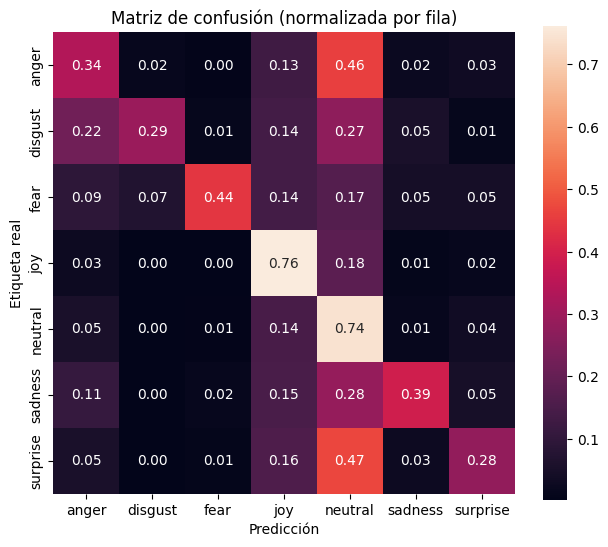

In [ ]:
# Punto 4:
# COMPLETAR: Evaluación en el conjunto de test

# Cálculo de las métricas detalladas en test y la matriz de confusión
def evaluate_model(model, loader, class_names, device=DEVICE, plot_cm=True):
    """
    Evalúa el modelo en 'loader' y muestra métricas + matriz de confusión.
    Devuelve un dict con accuracy, f1_macro y el report de sklearn.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, lengths, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x, lengths)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    report = classification_report(
        y_true, y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        digits=3
    )

    print("=== Test metrics ===")
    print(f"Accuracy: {100*acc:.2f}%")
    print(f"F1-score: {f1m:.4f}")
    print("\nClassification report (macro/por clase):")
    print(report)

    if plot_cm:
        cm = confusion_matrix(
            y_true, y_pred,
            labels=list(range(len(class_names)))
        )
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

        plt.figure(figsize=(6.5, 5.5))
        sns.heatmap(
            cm_norm, annot=True, fmt=".2f",
            xticklabels=class_names, yticklabels=class_names,
            cbar=True, square=True
        )
        plt.xlabel("Predicción")
        plt.ylabel("Etiqueta real")
        plt.title("Matriz de confusión (normalizada por fila)")
        plt.tight_layout()
        plt.show()

    return {"accuracy": acc, "f1_macro": f1m, "report": report}

test_results = evaluate_model(gru_model, test_loader, class_names=sorted(ekman_labels), device=DEVICE, plot_cm=True)

# Creamos un DataFrame vacío con los resultados de los distintos modelos que evaluamos
gru_results = {
    "model": ["GRU base"],
    "accuracy": [100.0 * test_results['accuracy']],
    "f1": [test_results['f1_macro']]
}

results_df = pd.DataFrame.from_dict(gru_results)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>RESPUESTA A LAS PREGUNTAS:</strong></p>
<ul>
    <li>
        <strong>Reporta las métricas macro (accuracy y F1-score) y detalladas por clase que has obtenido en el conjunto de test. ¿Cuál es la clase mejor clasificada y cuál la peor clasificada?</strong>
        <p>Las clases mejor clasificadas son <em>joy</em> y <em>neutral</em>, con F1-scores de 0.758 y 0.627, respectivamente. Estas clases, son también las más representadas en el conjunto de test. Las clases peor clasificadas son <em>disgust</em> y <em>surprise</em>, con un F1-score de 0.371 y 0.370, respectivamente. Disgust es la 2ª clase menos representada en el conjunto de training y test.</p>
    </li>
    <li>
        <strong>¿El modelo diferencia razonablemente las emociones o se observa solapamiento entre clases? Apóyate en la matriz de confusión.</strong>
        <p>El modelo clasifica ranablemente bien con las clases <em>joy</em> y <em>neutral</em>, con alrededor del 75% de accuracy obtenidas para estas. En cambio tienda a confundir bastante otras clases como <em>anger</em> (34% acc.), <em>disgust</em> (29% acc), o <em>surprise</em>, que las suele confundir con la clase <em>neutral</em>.</p>
    </li>
</ul>
</div>

# 4. Modelos basados en atención (2 puntos)

<div style="background-color: #edf7ff; border-color: #7c9dbf; border-left: 5px solid #7c9dbf; padding: 0.5em;">

---

<p><strong>Ejercicio [2 pts.]: Transformer simple para análisis de sentimiento en GoEmotions.</strong></p>

<p>
En este ejercicio construirás y entrenarás un modelo sencillo tipo <em>Transformer</em> para clasificar comentarios de <strong>GoEmotions</strong>. La arquitectura del modelo a implementar es la siguiente:
</p>

<ul>
  <li><strong>Capa de Embedding</strong> aprendible por el modelo (ver comentario más abajo).</li>
  <li><strong>Capa de self-Attention</strong> con <code>nn.MultiheadAttention</code> de 4 cabezas, enmascarando padding.</li>
  <li><strong>Conexión residual</strong> + <strong>LayerNorm</strong> sobre la salida de atención.</li>
  <li><strong>Pooling enmascarado</strong> (media sobre tokens reales, ignorando padding) con la función que os proporcionamos + <strong>Dropout</strong>.</li>
  <li><strong>Clasificador lineal</strong> que produce <em>logits</em> para las 7 clases.</li>
</ul>

<p>
Además, en este ejercicio introducimos dos novedades respecto a apartados anteriores:
</p>
<ul>
  <li><strong>Tokenizador de Hugging Face</strong>: aunque hablaremos más en detalle de la plataforma en el último ejercicio, en este apartado usa la función <code>AutoTokenizer.from_pretrained("bert-base-uncased")</code> de la librería <code>transformers</code> de Hugging Face para tokenizar los comentarios de GoEmotions, truncado a 128 tokens como máximo por secuencia. Como ventaja frente a la función <code>tokenize</code> usada en apartados anteriores, este tokenizador usa sub-palabras lo que reduce los problemas de palabras desconocidas (OOV), gestiona de forma más robusta mayúsculas y puntuación y aplica automáticamente padding y truncado según la longitud máxima definida.</li>
  <li><strong>Embeddings aprendibles</strong>: en lugar de usar embeddings GloVe preentrenados, el modelo entrenará su propia capa <code>nn.Embedding</code> de dimensión 128. Esta capa transforma los <em>tokens</em> del tokenizador a representaciones densas que se optimizan para la tarea.</li>
</ul>

<p><strong>TAREAS A REALIZAR:</strong></p>
<ol>
  <li>
    <strong>Implementación del modelo</strong> según la arquitectura descrita anteriormente.
  </li>
  <li>
    <strong>Entrada de datos</strong>: prepara los <code>DataLoader</code> y <code>collate_fn</code> usando el tokenizador de Hugging Face, pasando al modelo tripletas (<code>input_ids</code>, <code>attention_mask</code>, <code>labels</code>) para cada batch.
  </li>
  <li>
    <strong>Resultados y análisis</strong>:
    <ul>
      <li>Muestra por pantalla un <em>resumen</em> de la arquitectura del modelo y el número de parámetros entrenables del mismo .</li>
      <li>Entrena el modelo usando la función train_model() del ejercicio anterior y grafica las <strong>curvas de pérdida</strong> de <em>train</em> y <em>validation</em>.</li>
      <li>Evalúa en <em>test</em> usando la función evaluate_model() del ejercicio anterior y reporta las métricas de clasificación (accuracy, F1-score, matriz de confusión, etc).</li>
      <li><strong>Comparativa</strong>: compara los resultados con el obtenido en el ejercicio anterior. ¿Mejora este nuevo modelo los resultados obtenidos con la GRU?.</li>
    </ul>
  </li>
</ol>

</div>


---


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
# Punto 1
# COMPLETAR: Definición del modelo Transformer básico

class SimpleTransformer(nn.Module):
    """
    Mini-Transformer para clasificación de texto (multiclase, p. ej. 7 emociones de Ekman)
    con mean-pooling enmascarado (ignora padding).

    Bloques:
      - Capa de Embedding
      - Multi-Head Self-Attention (Q=K=V=x)
      - Conexión residual + LayerNorm
      - Pooling enmascarado + Dropout
      - Capa lineal final (logits)
    """
    def __init__(self, vocab_size, embed_dim, num_heads, num_classes,
                 pad_id=0, dropout=0.3):
        super().__init__()
        # ---- Capa de Embedding ----
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)

        # ---- Multi-Head Self Attention ----
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # ---- Normalización y residual ----
        self.norm = nn.LayerNorm(embed_dim)

        # ---- Regularización y clasificador ----
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)

    @staticmethod
    # Función masked_mean() proporcionada, sin necesidad de completar
    def masked_mean(x, attention_mask, eps: float = 1e-9):
        """
        x:              [B, T, E]
        attention_mask: [B, T] con 1 en tokens reales y 0 en padding
        Devuelve el promedio por secuencia ignorando padding: [B, E]
        """
        mask = attention_mask.unsqueeze(-1).type_as(x)   # [B, T, 1]
        x_masked = x * mask                               # pone a 0 los pads
        lengths = mask.sum(dim=1).clamp(min=1.0)          # [B, 1]
        return x_masked.sum(dim=1) / (lengths + eps)      # [B, E]

    def forward(self, input_ids, attention_mask):
        """
        input_ids:      [B, T] (tokens)
        attention_mask: [B, T] (1 = token real, 0 = padding)
        Devuelve logits: [B, num_classes]
        """
        # 1) Embeddings
        x = self.embedding(input_ids)  # [B, T, E]

        # 2) Self-attention (enmascarada para ignorar pads)
        # key_padding_mask espera True donde hay padding
        key_padding_mask = (attention_mask == 0)  # [B, T], True=pad
        attn_out, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask)  # [B, T, E]

        # 3) Residual + LayerNorm
        x = self.norm(x + attn_out)   # [B, T, E]

        # 4) Pooling enmascarado (media sobre tokens reales)
        x = self.masked_mean(x, attention_mask)  # [B, E]

        # 5) Dropout + Clasificador
        x = self.dropout(x)
        logits = self.classifier(x)   # [B, num_classes] (logits, sin softmax)
        return logits

In [ ]:
# Punto 2
# COMPLETAR: Carga del tokenizazor "bert-base-uncased" de Hugging Face y creación de los
# DataLoader y la función collate_fn para formación de mini-batches

# =========================
# 1) Tokenizer de Hugging Face
# =========================
tokenizer_hf = AutoTokenizer.from_pretrained("bert-base-uncased")
PAD_ID       = tokenizer_hf.pad_token_id #Índice del token de padding
MAX_SEQ_LEN  = 128  # Tamaño máximo de secuencia para el tokenizador (hace padding o trunca)
EMB_SIZE     = 128  # Tamaño de la capa de embedding
NUM_HEADS    = 4    # Nº de cabezas del MultiheadAttention

# Definición de la función collate para pasarle al DataLoader
# (Esta función no necesita modificación por vuestra parte)
def make_collate_fn_hf(tokenizer_fn, max_len=MAX_SEQ_LEN):
    """
    Crea una función 'collate_fn' para usar con DataLoader.
    Esta función:
      - Convierte tokens a vectores GloVe.
      - Hace padding hasta la longitud máxima del batch (o 'max_len' si se indica).
      - Devuelve longitudes reales de cada secuencia (para usar en pack_padded_sequence).

    Args:
        tokenizer_fn: función de tokenización.
        max_len: máxima longitud de sencuencia para padding/truncado.

    Returns:
        collate_fn: función para pasar a DataLoader.
    """
    def collate_fn(batch):
        # Extraemos los campos "text" y "label" del batch
        texts, labels = zip(*[(d["text"], d["labels"]) for d in batch])
        enc = tokenizer_fn(
            texts,
            padding="max_length",
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )
        return enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE), torch.tensor(labels).to(DEVICE)
    return collate_fn


# Creación de los DataLoaders a partir de los DataSets
def create_dataloaders_hf(dataset, tokenizer_fn):

  # ===== Collate function  =====
  collate_fn = make_collate_fn_hf(tokenizer_fn, MAX_SEQ_LEN)

  # ===== DataLoaders =====
  train_loader = DataLoader(
      dataset['train'],
      batch_size=BATCH_SIZE,
      shuffle=True,
      collate_fn=collate_fn
  )

  val_loader = DataLoader(
      dataset['validation'],
      batch_size=BATCH_SIZE,
      shuffle=False,
      collate_fn=collate_fn
  )

  test_loader = DataLoader(
      dataset['test'],
      batch_size=BATCH_SIZE,
      shuffle=False,
      collate_fn=collate_fn
  )

  return train_loader, val_loader, test_loader

📐 Arquitectura del modelo:
SimpleTransformer(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=7, bias=True)
)
------------------------------------------------------------
📊 Parámetros totales: 3,974,023
✅ Parámetros entrenables: 3,974,023
⚙️ Parámetros congelados: 0
------------------------------------------------------------
[01] Train → loss=1.2266, acc=54.22% | Val → loss=1.0761, acc=60.25% ✅ | lr=2.00e-03
[02] Train → loss=1.0031, acc=63.36% | Val → loss=1.0201, acc=61.48% ✅ | lr=2.00e-03
[03] Train → loss=0.8926, acc=67.38% | Val → loss=1.0274, acc=62.03% ⚠️ | lr=2.00e-03
[04] Train → loss=0.7949, acc=71.11% | Val → loss=1.0631, acc=62.11% ⚠️ | lr=2.00e-03
[05] Train → loss=0.7074, acc=74.

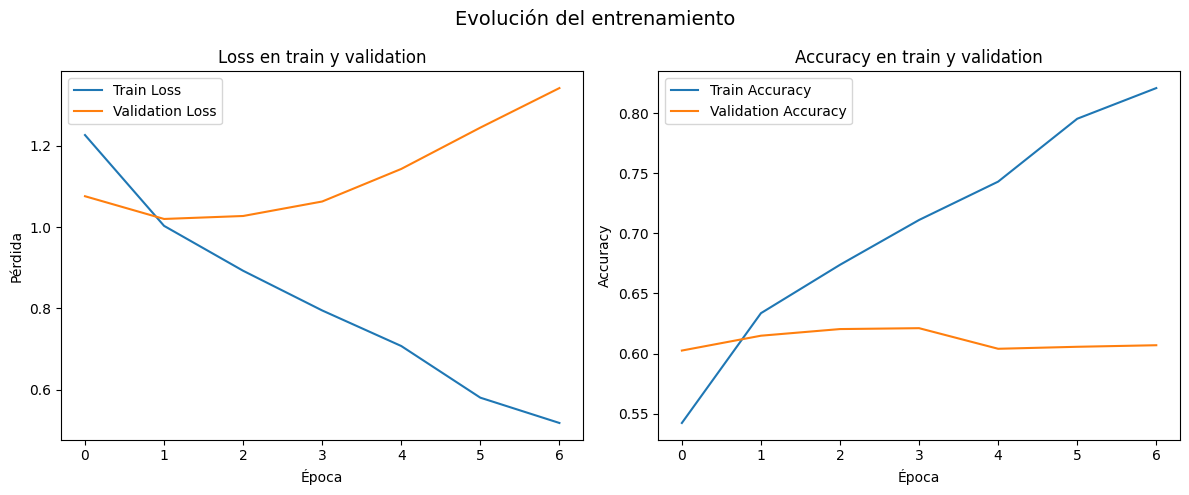

=== Test metrics ===
Accuracy: 61.18%
F1-score: 0.5176

Classification report (macro/por clase):
              precision    recall  f1-score   support

       anger      0.460     0.377     0.414       647
     disgust      0.516     0.337     0.408        95
        fear      0.690     0.455     0.548        88
         joy      0.703     0.811     0.753      1993
     neutral      0.568     0.610     0.588      1699
     sadness      0.603     0.390     0.473       331
    surprise      0.505     0.387     0.438       574

    accuracy                          0.612      5427
   macro avg      0.578     0.481     0.518      5427
weighted avg      0.601     0.612     0.601      5427



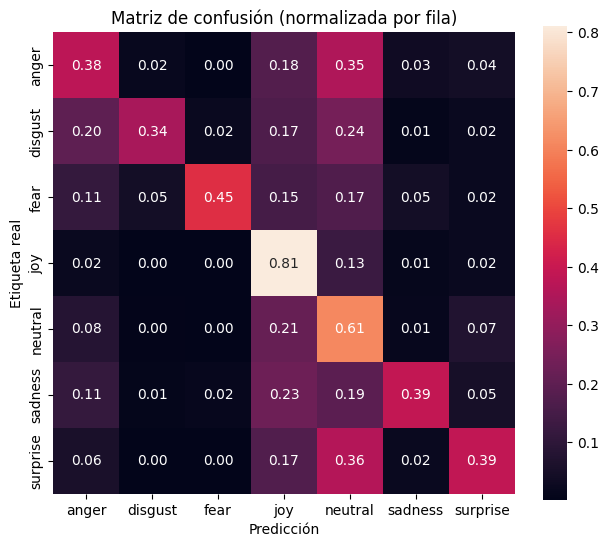


Tabla de Resultados Global:
                model   accuracy        f1
0            GRU base  61.783674  0.498944
1  Transformer básico  61.175603  0.517559


In [ ]:
# Punto 3
# COMPLETAR: Entrenamiento y evaluación del modelo Transformer básico

# =====================================================
# 1. Boiler plate: creación de dataloader, modelo, loss, etc
# =====================================================
train_loader, val_loader, test_loader = create_dataloaders_hf(
    dataset=ds_ekman,
    tokenizer_fn=tokenizer_hf
)

simple_transformer_model = SimpleTransformer(vocab_size=tokenizer_hf.vocab_size,
                                             embed_dim=EMB_SIZE,
                                             num_heads=NUM_HEADS,
                                             num_classes=NUM_CLASSES,
                                             pad_id=tokenizer_hf.pad_token_id,
                                             dropout=0.3).to(DEVICE)
summary_model(simple_transformer_model)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(simple_transformer_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
)

# =====================================================
# 2. Entrenamiento del modelo
# =====================================================
simple_transfomer_model = train_model(model=simple_transformer_model,
                                      train_loader=train_loader,
                                      val_loader=val_loader,
                                      optimizer=optimizer,
                                      criterion=criterion,
                                      epochs=EPOCHS,
                                      max_patience=MAX_PATIENCE,
                                      scheduler=scheduler,
                                      plot_curves=True)

# =====================================================
# 3. Evaluación en test
# =====================================================
test_results = evaluate_model(simple_transfomer_model,
                              test_loader,
                              class_names=sorted(ekman_labels),
                              device=DEVICE,
                              plot_cm=True)

# Resultados del modelo Transformer básico implementado
transformer_results = {
    "model": "Transformer básico",
    "accuracy": 100.0 * test_results['accuracy'],
    "f1": test_results['f1_macro']
}

# Añadir fila a la tabla de resultados
results_df = pd.concat([results_df, pd.DataFrame([transformer_results])], ignore_index=True)

print()
print('Tabla de Resultados Global:')
print(results_df)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>COMENTARIOS SOBRE LOS RESULTADOS OBTENIDOS:</strong></p>
El modelo Transformer implmentado obtiene resultados similares a los de la GRU básica (accuracy ≈ 62 % y F1 macro ≈ 0.54) pese a tener más de 10 veces el número de parámetros (≈ 4 M frente a ≈ 0,24 M).
Aunque en el cojunto de entrenamiento la pérdida y la accuracy siguen mejorando varias épocas, en validación sólo mejoran al principio y luego empeoran, lo que indica sobreajuste al reducido tamaño del dataset y explica que el modelo no supere a los modelos GRU del apartado anterior.
</div>

# 5. Modelos preentrenados (Hugging Face) (4 puntos)

En los apartados anteriores de esta práctica hemos trabajado con modelos que entrenamos desde cero (como la GRU y el Transformer simple) o que usan embeddings pre-calculados (como GloVe). Sin embargo, como hemos comentado, los modelos basados en transformers suponen muchos avances respecto a otras arquitecturas, pero requieren de una gran cantidad de datos y capacidad de cómputo para poder aprender cantidades tan grandes de parámetros de forma efectiva durante su entrenamiento. Por eso, a día de hoy, resulta más práctico aprovechar el conocimiento que otros modelos ya han adquirido durante su entrenamiento y adaptarlos para resolver otras tareas. Aquí es donde entran los **modelos pre-entrenados** y plataformas como **Hugging Face**.

Imaginemos que alguien ha podido acceder a una cantidad gigantesca de texto de internet (Wikipedia, libros, artículos, conversaciones...) y ha construido un modelo capaz de entender patrones del lenguaje: cómo se relacionan las palabras, qué contextos son similares, incluso algo de gramática y semántica. Ese es, a grandes rasgos, un **modelo pre-entrenado**. Se le llama así porque ya ha pasado por una fase de "pre-entrenamiento" intensivo en una tarea general (como predecir la siguiente palabra o rellenar huecos en frases) usando una cantidad masiva de datos y recursos computacionales que habitualmente no tenemos a nuestro alcance.

La gran ventaja es que estos modelos ya tienen una base sólida de "comprensión" del lenguaje. En lugar de empezar de cero para cada nueva tarea de NLP (como clasificar emociones, traducir o responder preguntas), podemos partir de este modelo pre-entrenado y adaptarlo.

**Hugging Face** se ha convertido en la plataforma de referencia para encontrar y usar estos modelos. En concreto, la librería `transformers` permite descargar modelos ya entrenados (como BERT, RoBERTa, GPT-2, etc.) con una cantidad reducida de código y usarlos fácilmente con PyTorch, como es nuestro caso, pero también con TensorFlow o JAX. También ofrecen datasets y herramientas adicionales que facilitan el trabajo y adaptación a distintos proyectos de NLP. En resumen, nos va a dar acceso a modelos de vanguardia listos para usar.

### Adaptación de un modelo pre-entrenado para otras tareas (Downstream Tasks)

En esta sección, veremos cómo utilizar un modelo de lenguaje tipo transformer (BERT) descargado de HuggingFace para adaptarlo para la realización de una tarea específica (**downstream task**). En este caso, nuestra downstream task es la clasificación clasificación de los comentarios de **GoEmotions** en las 7 categorías de Ekman. Este proceso de adaptación se conoce como **fine-tuning**, y va a conllevar tres partes principales:

-  **Carga del modelo pre-entrenado**. En este caso utilizaremos un modelo BERT, que entiende de lenguaje general. En concreto, te proponemos utilizar el modelo `bert-base-uncase`. Puedes acceder a toda la información sobre su origen, entrenamiento, particularidades, etc. en [bert-base-uncase HF](https://huggingface.co/google-bert/bert-base-uncased).
-  **Adaptación para la clasificación de emociones**. Puesto que el modelo original no se ha entrenado para la tarea de clasificación de 7 emociones, necesitamos modificarlo, añadiendo una capa densa al final que nos diga la probabilidad de cada emoción a través de una puntuación, como hacemos en cualquiera de los modelos de los primeros apartados de la práctica.
-  **Entrenamiento del modelo**. El modelo al que hemos añadido la nueva capa necesita ser entrenado de nuevo durante varias épocas para ser capaz de adaptarse a nuestra tarea. La realización de este paso de forma óptima requiere de mucho conocimiento de hiperparámetros, métodos de optimización y, sobretodo, mucha práctica para evitar problemas como el conocido fenómeno de [Catastrophic Forgetting](https://arxiv.org/pdf/1905.05583v3).

En las siguientes secciones veremos dos posibilidades de entrenamiento del modelo y sus diferencias, y los compararemos con los resultados obtenidos en los modelos anteriores:
1. **Entrenamiento de todas las capas** de nuevo durante un número pequeño de épocas.
2. **Entrenamiento únicamente de la nueva capa** añadida para clasificación, dejando congeladas el resto (las capas ya entrenadas del modelo BERT).


## 5.1. Fine-tuning completo de BERT (2 puntos)


---

<div style="background-color: #edf7ff; border-color: #7c9dbf; border-left: 5px solid #7c9dbf; padding: 0.5em;">

**Ejercicio [2.0 pts.]** En este primer ejercicio vamos a aplicar la técnica de fine-tuning sobre el modelo BERT pre-entrenado (`bert-base-uncased`) para adaptarlo a nuestra tarea de clasificación de emociones. En este caso, vamos a utilizar la API `Trainer` de la librería `transformers` de Hugging Face para gestionar el proceso de entrenamiento y evaluación. Te recomendamos que leas la documentación en detalle para entender su funcionamiento interno y cómo aprovechar al máximo sus argumentos para optimizar los resultados a nuestro problema: [API Trainer HF](hhttps://huggingface.co/docs/transformers/trainer).

Sigue los siguientes pasos para la realización de este ejercicio:

1.  **Preparación de datos para el Trainer:**
    *   El `Trainer` de Hugging Face trabaja de forma directa con los objetos `Dataset` de la librería `datasets` una vez que estos contienen las entradas tokenizadas.
    *   Tokeniza los datasets de `train`, `validation` y `test`. Esto añadirá columnas como `input_ids`, `attention_mask` y `token_type_ids` a los datasets. Trunca utilizando el mismo `MAX_SEQ_LEN` que en ejercicios anteriores. ***Importante***: Ten en cuenta que cuando utilices un modelo pre-entrenado siempre debes utilizar el mismo tokenizador con el que se ha entrenado dicho modelo. En este caso, el modelo BERT que vas a usar. En HuggingFace puedes importar `AutoTokenizer` de la librería `transformers`, que carga automáticamente el tokenizador asociado al modelo que vas a utilizar.
    *   Asegúrate de que el dataset tokenizado tenga las columnas esperadas por el `Trainer` (especialmente la columna de etiquetas, que debe llamarse `labels` y en caso contrario tendrás que renombrarla).

2.  **Definición de Métricas de Evaluación:**
    *   El `Trainer` necesita una función que calcule las métricas de rendimiento (**accuracy** y **F1-score**) sobre el conjunto de validación durante el entrenamiento y en el conjunto de test al finalizar.
    *   Define la función `compute_metrics` que reciba un objeto `EvaluationPrediction` (con las predicciones y etiquetas reales) y devuelva un diccionario con las métricas deseadas. Esta función se le pasa directamente como arguento al Trainer así que dentro de esa función, asume como primer paso que puedes desglosar dicho objeto como se propone en el siguiente ejemplo:


    ```
    def compute_metrics(eval_pred):
        logits, label_ids = eval_pred
        predictions = logits.argmax(axis=-1) # Quédate con la clase más probable

        # Aplica las mismas métricas que en los apartados del transformer simple y GRU
        # ...

        return metricas

    ```


3.  **Configuración del entrenamiento (`TrainingArguments`):**
    *   Utiliza la clase `TrainingArguments` para definir todos los hiperparámetros y configuraciones para el entrenamiento (número de épocas, tamaño del batch, learning rate, estrategia de evaluación, directorios de salida, etc.).
    *   Para empezar, puedes probar con una configuración clásica, por ejemplo: 3-5 épocas, batch size de `64` y `learning_rate` inicial alrededor de `2e-5`. Además, configura el Trainer para que:
        * la evaluación ocurra al final de cada época
        * se guarde el mejor modelo basado en la métrica F1 macro
        * los checkpoints del modelo se guarden en el directorio "./results"
        * los logs del modelo se guarden cada 2 steps en el directorio "./logs"
        * no se reporten resultados a ninguna plataforma (`report_to = 'none'`)
        
      Consulta la documentación para ayudarte a encontrar los argumentos adecuados [TrainingArgs Documentation](https://huggingface.co/docs/transformers/v4.57.0/en/main_classes/trainer#transformers.TrainingArguments).

4.  **Carga del modelo pre-entrenado:**
    *   Carga el modelo `bert-base-uncased` utilizando `AutoModelForSequenceClassification.from_pretrained()`, especificando el número correcto de clases (`NUM_CLASSES=7`). Esto cargará los pesos pre-entrenados y añadirá una capa de clasificación aleatoria al final.

5.  **Instancia y ejecución del Trainer:**
    *   Crea una instancia de la clase `Trainer`, pasándole el modelo cargado, los `TrainingArguments`, los datasets tokenizados de entrenamiento y validación (`tokenized_datasets["train"]` y `tokenized_datasets["validation"]`), la función `compute_metrics` y el tokenizer que hayas utilizado, y que también necesita internamente el Trainer.

    *   Llama al método `trainer.train()` para iniciar el proceso de fine-tuning. Observa la salida del Trainer para seguir el progreso del entrenamiento y las métricas de validación por época.

6.  **Evaluación final en Test:**
    * 6a. -   Una vez finalizado el entrenamiento (el `Trainer` cargará automáticamente el mejor modelo si lo configuraste como se solicita en el apartado 3), utiliza `trainer.evaluate()` con el dataset de test tokenizado `tokenized_datasets["test"]` para obtener las métricas finales de rendimiento.
    * 6b. - Para conocer un poco más sobre `Trainer` y facilitar la comparación con ejercicios anteriores: extiende la función de creación de métricas para que devuelva, además de accuracy y F1, el informe de clasificación y la matriz de confusión utilizando las predicciones del Trainer y las funciones de `sklearn.metrics` para un análisis más detallado por clase, tal y como se sugería para la GRU. Adapta la función para que dado nuestro `trainer`, el dataset de test tokenizado `tokenized_datasets["test"]` y las etiquetas textuales de Ekman disponibles en nuestro dataset de Ekman `sorted(set(ds_ekman["train"]["class"]))`, utiliza el método `trainer.predict()` para hacer inferencia con el modelo ya entrenado y poder calcular estas métricas específicas o hacer las operaciones pertinentes.

7. **Comparación de resultados con GRU y Transformer Simple**:
    * Una vez terminado, compara los resultados de las métricas obtenidas con este modelo sobre el conjunto de test contra los resultados obtenidos para la GRU y el Transformer simple. ¿Se obtienen mejoras en la identificación de clases? ¿Sigues observando solapamiento?



---



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
# Configuración:
# Los siguientes parámetros están definidos al inicio del notebook, pero se pueden descomentar
# para lanzar únicamente esta parte
#
# MAX_SEQ_LEN  = 128
# NUM_CLASSES = 7
# BATCH_SIZE = 64
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Punto 1
# COMPLETAR: Preparación de datos para el Trainer

def tokenize_function(examples):
    return tokenizer_hf(examples["text"], padding="max_length", truncation=True, max_length=MAX_SEQ_LEN)

tokenizer_hf = AutoTokenizer.from_pretrained("bert-base-uncased")
tokenized_datasets = ds_ekman.map(tokenize_function, batched=True)

# Eliminar columna 'text' y renombrar 'labels' para compatibilidad con el Trainer
tokenized_datasets = tokenized_datasets.remove_columns(["text", "class"])
# tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

print("Tokenized datasets structure:")
print(tokenized_datasets)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Tokenized datasets structure:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5427
    })
})


In [ ]:
# Punto 2
# COMPLETAR: Definición de Métricas de Evaluación

# Definoción de una función para calcular métricas de evaluación y dársela como
# argumento al Trainer

def compute_metrics(eval_pred):
    """
    Función para calcular métricas de evaluación para el Trainer de Hugging Face.

    Args:
        eval_pred: Objeto EvaluationPredición que contiene:
            - predictions: array numpy con los logits del modelo.
            - label_ids: array numpy con las etiquetas reales.

    Returns:
        Un diccionario con las métricas calculadas (accuracy, f1_macro).
    """
    logits, label_ids = eval_pred
    # Las predicciones son los índices de la clase con mayor logit
    predictions = logits.argmax(axis=-1)

    # Calcula las métricas
    accuracy = accuracy_score(label_ids, predictions)
    f1_macro = f1_score(label_ids, predictions, average='macro')

    return {"accuracy": accuracy, "f1_macro": f1_macro}

In [ ]:
# Punto 3
# COMPLETAR: Configuración del entrenamiento

from transformers import TrainingArguments

output_dir = "./results"  # Directorio donde se guardarán los checkpoints
logging_dir = "./logs"    # Directorio para los logs

training_args = TrainingArguments(
    output_dir=output_dir,                  # Directorio de salida
    logging_dir=logging_dir,                # Directorio para los logs de TensorBoard
    num_train_epochs=5,                     # Número de épocas de entrenamiento (se puede ajustar)
    per_device_train_batch_size=BATCH_SIZE, # Tamaño del batch por dispositivo durante el entrenamiento
    per_device_eval_batch_size=BATCH_SIZE,  # Tamaño del batch por dispositivo durante la evaluación
    #warmup_steps=500,                      # Número de pasos para el warmup del learning rate ---> Para ejercicio 5.3
    #weight_decay=0.01,                     # Regularización ---> Para ejercicio 5.3
    learning_rate = 2e-5,                   # Learning_rate valor constante
    logging_steps=2,                        # Cada cuántos pasos se loguean las métricas
    eval_strategy="epoch",                  # Evaluar al final de cada época
    save_strategy="epoch",                  # Guardar checkpoint al final de cada época
    load_best_model_at_end=True,            # Cargar el mejor modelo al finalizar el entrenamiento
    metric_for_best_model="f1_macro",       # Métrica para determinar el mejor modelo
    greater_is_better=True,                 # Si una mayor métrica_para_mejor_modelo es mejor
    report_to="none",                       # No reportar a ninguna plataforma externa por defecto (ej. "tensorboard")
)

print("Training Arguments definidos:")
print(training_args)

Training Arguments definidos:
TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,

In [ ]:
# Punto 4
# COMPLETAR: Carga del modelo pre-entrenado

# Debes tener importadas las siguientes librerías:
# from transformers import Trainer, AutoModelForSequenceClassification

# Cargar el modelo BERT preentrenado para clasificación de secuencias (de nuevo para independencia)
model_name = "bert-base-uncased"
# Asegurarse de que num_labels coincide con el número de clases de Ekman
model_hf_trainer = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_CLASSES)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Punto 5
# COMPLETAR: Instanciamiento el Trainer y entrenamiento

# Instanciar el Trainer
trainer = Trainer(
    model=model_hf_trainer,                 # El modelo a entrenar
    args=training_args,                     # Los argumentos de entrenamiento definidos anteriormente
    train_dataset=tokenized_datasets["train"],        # Dataset de entrenamiento (usar dataset tokenizado)
    eval_dataset=tokenized_datasets["validation"],    # Dataset de validación (usar dataset tokenizado)
    compute_metrics=compute_metrics,        # Función para calcular métricas de evaluación definida en punto 2
    processing_class=tokenizer_hf,                 # El tokenizer (necesario para algunas funcionalidades del Trainer y mantener reproducibilidad a futuro)
)

# Entrenar el modelo
print("\n--- Iniciando entrenamiento con Hugging Face Trainer ---")
trainer.train()

print("--- Entrenamiento finalizado ---")


--- Iniciando entrenamiento con Hugging Face Trainer ---


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.839400,0.842152,0.683745,0.600285
2,0.691700,0.828443,0.690564,0.623961
3,0.770400,0.855199,0.689827,0.625134
4,0.794000,0.916345,0.686141,0.619150
5,0.567600,0.949284,0.684851,0.620430


--- Entrenamiento finalizado ---


In [ ]:
# Punto 6a
# COMPLETAR: Evaluación del modelo en Test

# Evaluar el mejor modelo en el conjunto de test
print("\n--- Evaluando el mejor modelo en el conjunto de test con el Trainer ---")

# El Trainer carga automáticamente el mejor modelo al final si load_best_model_at_end=True
test_results = trainer.evaluate(tokenized_datasets["test"])

print("Resultados de la evaluación en el conjunto de test:")
print(test_results)



--- Evaluando el mejor modelo en el conjunto de test con el Trainer ---


Resultados de la evaluación en el conjunto de test:
{'eval_loss': 0.8675048351287842, 'eval_accuracy': 0.6823290952644187, 'eval_f1_macro': 0.6075238070938803, 'eval_runtime': 35.8133, 'eval_samples_per_second': 151.536, 'eval_steps_per_second': 2.373, 'epoch': 5.0}


In [ ]:
# Punto 6b
# COMPLETAR: Visualización de nuevas métricas sobre el conjunto de Test

# Extensión de la función compute_metrics() --> compute_metrics_from_test()

def compute_metrics_from_test(trainer, dataset_test, class_names):
    """
    Función para calcular métricas sobre los datos de test usando el método .predict() del Trainer.

    Args:
        trainer: Trainer de Hugging Face de nuestro modelo ya entrenado
        dataset_test: Dataset de test tokenizado sobre el que calcularemos las métricas
        class_names: Nombres de las clases de las emociones (únicas)

    Returns:
        Un diccionario con las métricas calculadas (accuracy, f1_macro), el report y la matriz de confusión.
    """
    # Obtención de predicciones del Trainer en el conjunto de test
    # El arg metric_key_prefix puesto a 'test' por claridad en el output
    predictions_output = trainer.predict(dataset_test, metric_key_prefix="test")

    # Extrae predicciones (logits) y etiquetas
    test_predictions_logits = predictions_output.predictions
    test_label_ids = predictions_output.label_ids

    # Quédate con la más probable
    test_predicted_labels = np.argmax(test_predictions_logits, axis=-1)

    # Cálculo de métricas
    accuracy = accuracy_score(test_label_ids, test_predicted_labels)
    f1_macro = f1_score(test_label_ids, test_predicted_labels, average='macro')

    # Calcular report (como en otros apartados)
    report = classification_report(test_label_ids, test_predicted_labels, labels=list(range(len(class_names))), target_names=class_names, digits=3)
    cm = confusion_matrix(test_label_ids, test_predicted_labels, labels=list(range(len(class_names))))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    # Prints and visualizations
    print("=== Test metrics ===")
    print(f"Accuracy: {100*accuracy:.2f}%")
    print(f"F1-score: {f1_macro:.4f}")
    print("\nClassification report (macro/por clase):")
    print(report)

    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f",
        xticklabels=class_names, yticklabels=class_names,
        cbar=True, square=True
    )
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta real")
    plt.title("Matriz de confusión (normalizada por fila)")
    plt.tight_layout()
    plt.show()


    # Calcula las métricas
    accuracy = accuracy_score(test_label_ids, test_predicted_labels)
    f1_macro = f1_score(test_label_ids, test_predicted_labels, average='macro')

    return {"accuracy": accuracy, "f1_macro": f1_macro, "report": report}



--- Generando predicciones en el conjunto de test para análisis detallado, métricas y visualizaciones ---


=== Test metrics ===
Accuracy: 68.23%
F1-score: 0.6075

Classification report (macro/por clase):
              precision    recall  f1-score   support

       anger      0.535     0.552     0.544       648
     disgust      0.567     0.366     0.444        93
        fear      0.645     0.674     0.659        89
         joy      0.790     0.843     0.816      1989
     neutral      0.673     0.614     0.642      1694
     sadness      0.636     0.505     0.563       333
    surprise      0.545     0.632     0.585       581

    accuracy                          0.682      5427
   macro avg      0.627     0.598     0.608      5427
weighted avg      0.681     0.682     0.680      5427



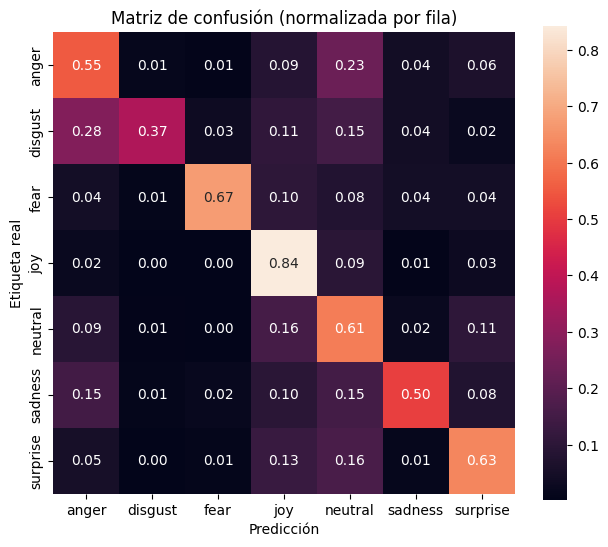


Tabla de Resultados Global:
              model   accuracy        f1
0          GRU base  61.838953  0.513359
1      GRU mejorado  63.902709  0.568152
2  Transformer base  62.023217  0.523347
3  BERT fine-tuning  68.232910  0.607524


In [ ]:
# Punto 6b (continuación)
# COMPLETAR:

# Visualización de las métricas y matriz definidas en la función compute_metrics_from_test() sobre el dataset de test
print("\n--- Generando predicciones en el conjunto de test para análisis detallado, métricas y visualizaciones ---")

# Obtención de los nombres de las clases de Ekman en el orden correcto
ekman_labels_sorted = sorted(set(ds_ekman["train"]["class"]))

test_results = compute_metrics_from_test(trainer, tokenized_datasets["test"], class_names=sorted(ekman_labels))

# Crea un DataFrame nuevo con los resultados de los distintos modelos que evaluamos
finetuning_bert_results = {
    "model": ["BERT fine-tuning"],
    "accuracy": [100.0 * test_results['accuracy']],
    "f1": [test_results['f1_macro']]
}

# Añadir fila a la tabla de resultados
results_df = pd.concat([results_df, pd.DataFrame.from_dict(finetuning_bert_results)], ignore_index=True)

print()
print('Tabla de Resultados Global:')
print(results_df)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>PUNTO 7: Comparación de resultados con GRU y Transformer simple:</strong></p>
<ul>
    <li>
        <strong>Una vez terminado, compara los resultados de las métricas obtenidas con este modelo sobre el conjunto de test contra los resultados obtenidos para la GRU y el Transformer simple. ¿Se obtienen mejoras en la identificación de clases? ¿Sigues observando solapamiento?</strong>
        <p> En cuanto a la evolución del entrenamiento, vemos que las métricas sobre el conjunto de  validación mejoran en la primera y segunda época, pero que empiezan a empeorar a partir de la tercera. Esto sugiere un comienzo de overfitting sobre el dataset de entrenamiento debido a la  gran cantidad de parámetros que estamos re-entrenando, comparado con el tamaño de nuestro dataset, así como la necesidad de usar métodos para paliarlo. </p>
        <p>Se observa que tras la realización de fine-tuning la identificación de las emociones ha mejorado en todas ellas notablemente. En particular, vemos que comparado con los resultados obtenidos para la GRU, el solapamiento entre emociones como 'anger' y 'disgust' ha mejorado notablemente. La accuracy global ha aumentado de 64% aprox a 67%. En este caso, más que el valor de accuracy global, parece que la principal ventaja de este modelo es que es capaz de utilizar información oculta para identificar emociones que no están tan representadas en nuestro dataset inicial.</p>
    </li>
</ul>
</div>


## 5.2. Fine-tuning de la capa de clasificación (1.5 puntos)


---

<div style="background-color: #edf7ff; border-color: #7c9dbf; border-left: 5px solid #7c9dbf; padding: 0.5em;">

**Ejercicio [1.5 pts.]** En esta sección, vamos a comparar el rendimiento de ajustar (**fine-tuning**) el modelo BERT completo (como hicimos en el apartado 5.1) frente a una estrategia alternativa: entrenar únicamente la capa de clasificación final, manteniendo las capas base del modelo BERT **congeladas**. Esto nos permitirá evaluar si es suficiente entrenar solo la parte del modelo específica para la tarea o si es necesario ajustar también las representaciones aprendidas en el pre-entrenamiento.

Utilizaremos el `Trainer` de Hugging Face nuevamente, pero realizaremos una configuración manual previa en el modelo.

Sigue los pasos siguientes para la realización del ejercicio:

1.  **Cargar una nueva instancia del modelo BERT**: Es importante empezar con una instancia limpia del modelo pre-entrenado para asegurarnos de que no arrastra pesos del entrenamiento anterior. Cargamos de nuevo el modelo `"bert-base-uncased"` adaptado para clasificación de las 7 categorías de Ekman. Calcula el número de parámetros entrenables para el modelo en este punto.

2.  **Congelar capas base de BERT**: Este es el paso clave y novedoso de esta sección. Antes de pasar el modelo al `Trainer`, iteraremos sobre todos sus parámetros y estableceremos `param.requires_grad = False` para todas las capas **excepto** la capa de clasificación final, que en los modelos de Hugging Face suele llamarse `classifier`. Esto indica a PyTorch que no calcule los gradientes ni actualice los pesos de las capas congeladas durante el entrenamiento. Utiliza `name, param in bert_model_frozen.named_parameters()` para la asignación.

3.  **Verificar parámetros entrenables**: Para confirmar que la congelación se realizó correctamente, muestra cuántos parámetros del modelo están marcados como entrenables. Debería ser un número mucho menor que el total de parámetros del modelo completo.

4.  **Instanciar y entrenar Trainer (solo capa final)**: Una vez que el modelo tiene las capas base congeladas, instanciamos la clase `Trainer` de la misma manera que en el apartado 5.1, pasándole este modelo modificado (`bert_model_frozen`), los mismos `TrainingArguments`, los datasets tokenizados anteriormente y la función `compute_metrics`. El `Trainer` respetará la configuración de `requires_grad` y solo entrenará los parámetros no congelados. Ejecuta `trainer.train()`. **Comenta los resultados**.

5.  **Evaluar en Test (solo capa final)**: Finalmente, evaluaremos el rendimiento de este modelo (con solo la capa final entrenada) en el conjunto de test utilizando `trainer.evaluate()`, al igual que hicimos en el apartado anterior. Evalúa también el informe de clasificación y la matriz de confusión. **Comenta los resultados**.

6. **Comparación de métodos de fine-tuning**: Compara los resultados obtenidos con los del fine-tuning completo para entender el impacto de entrenar solo la capa final.


---



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
# Punto 1
# COMPLETAR: Cargar una nueva instancia del modelo BERT

# Cargar el modelo BERT pre-entrenado para clasificación de secuencias
# Especificar el número de etiquetas (7 emociones de Ekman)
model_name = "bert-base-uncased"
bert_model_frozen = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_CLASSES)

# Mover el modelo al dispositivo
bert_model_frozen.to(DEVICE)

# Mostrar un resumen del modelo (opcional)
print("Arquitectura del modelo BERT para congelar capas:")
print(bert_model_frozen)

# Contar parámetros totales
total_params_frozen = sum(p.numel() for p in bert_model_frozen.parameters())

print("-" * 60)
print(f" Parámetros totales: {total_params_frozen:,}")
print("-" * 60)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Arquitectura del modelo BERT para congelar capas:
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
 

In [ ]:
# Punto 2
# COMPLETAR: Congelar capas base de BERT

print("--- Congelando capas base de BERT ---")

# Iterar sobre todos los parámetros del modelo
for name, param in bert_model_frozen.named_parameters():
    # Congelar el parámetro si NO pertenece a la capa de clasificación ('classifier')
    if 'classifier' not in name:
        param.requires_grad = False
        # print(f"Congelado: {name}") # Para verificar qué capas se congelan
    # else:
        # print(f"Entrenable: {name}") # Para verificar qué capas quedan entrenables

print("Congelación de capas base completada.")

--- Congelando capas base de BERT ---
Congelación de capas base completada.


In [ ]:
# Punto 3
# COMPLETAR: Verificar parámetros entrenables

trainable_params_frozen = sum(p.numel() for p in bert_model_frozen.parameters() if p.requires_grad)
frozen_params_frozen = total_params_frozen - trainable_params_frozen

print("-" * 60)
print(f" Parámetros entrenables después de congelar: {trainable_params_frozen:,}")
print(f" Parámetros congelados después de congelar: {frozen_params_frozen:,}")
print("-" * 60)

# Verificar que solo los parámetros del clasificador son entrenables
for name, param in bert_model_frozen.named_parameters():
    if param.requires_grad:
        print(f"Parámetro entrenable: {name} (shape: {param.shape})")

------------------------------------------------------------
 Parámetros entrenables después de congelar: 5,383
 Parámetros congelados después de congelar: 109,482,240
------------------------------------------------------------
Parámetro entrenable: classifier.weight (shape: torch.Size([7, 768]))
Parámetro entrenable: classifier.bias (shape: torch.Size([7]))


In [ ]:
# Punto 4
# COMPLETAR: Instanciar y entrenar (capa final solo)

# Instanciar el Trainer con el modelo donde las capas base están congeladas
trainer_frozen = Trainer(
    model=bert_model_frozen,                 # El modelo con capas base congeladas
    args=training_args,                     # Los mismos argumentos de entrenamiento
    train_dataset=tokenized_datasets["train"],        # Dataset de entrenamiento tokenizado
    eval_dataset=tokenized_datasets["validation"],    # Dataset de validación tokenizado
    compute_metrics=compute_metrics,        # Misma función para calcular métricas
    processing_class=tokenizer_hf,                 # El tokenizer
)

# Entrenar el modelo
print("\n--- Iniciando entrenamiento con Hugging Face Trainer (solo capa final) ---")
trainer_frozen.train()

print("--- Entrenamiento con capa final finalizado ---")


--- Iniciando entrenamiento con Hugging Face Trainer (solo capa final) ---


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.517700,1.499710,0.390343,0.093178
2,1.543500,1.487761,0.397530,0.096033
3,1.483300,1.481253,0.401216,0.099596
4,1.551700,1.476393,0.414302,0.113648
5,1.488100,1.475102,0.415039,0.114249


--- Entrenamiento con capa final finalizado ---


In [ ]:
# Punto 5
# COMPLETAR: Evaluar en Test (solo capa final)

print("\n--- Evaluando modelo BERT (solo capa final entrenada) en el conjunto de test ---")

# Evaluar el modelo congelado en el conjunto de test
test_results_frozen = trainer_frozen.evaluate(tokenized_datasets["test"])

print("Resultados de la evaluación en el conjunto de test (solo capa final entrenada):")
print(test_results_frozen)


--- Evaluando modelo BERT (solo capa final entrenada) en el conjunto de test ---


Resultados de la evaluación en el conjunto de test (solo capa final entrenada):
{'eval_loss': 1.4941009283065796, 'eval_accuracy': 0.3969043670536208, 'eval_f1_macro': 0.10934606058267425, 'eval_runtime': 35.5069, 'eval_samples_per_second': 152.844, 'eval_steps_per_second': 2.394, 'epoch': 5.0}



--- Generando predicciones en el conjunto de test para análisis detallado, métricas y visualizaciones ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


=== Test metrics ===
Accuracy: 39.69%
F1-score: 0.1093

Classification report (macro/por clase):
              precision    recall  f1-score   support

       anger      0.000     0.000     0.000       648
     disgust      0.000     0.000     0.000        93
        fear      0.000     0.000     0.000        89
         joy      0.386     0.969     0.552      1989
     neutral      0.528     0.134     0.214      1694
     sadness      0.000     0.000     0.000       333
    surprise      0.000     0.000     0.000       581

    accuracy                          0.397      5427
   macro avg      0.131     0.158     0.109      5427
weighted avg      0.306     0.397     0.269      5427



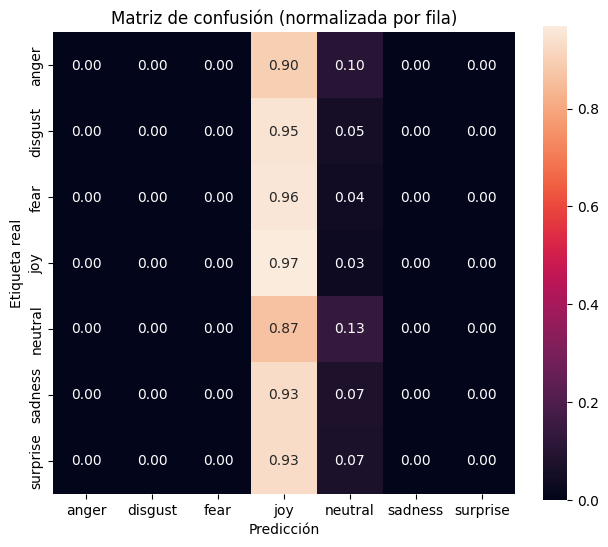


Tabla de Resultados Global:
                     model   accuracy        f1
0                 GRU base  61.838953  0.513359
1             GRU mejorado  63.902709  0.568152
2         Transformer base  62.023217  0.523347
3         BERT fine-tuning  68.232910  0.607524
4  BERT fine-tuning frozen  39.690437  0.109346


In [ ]:
# Punto 5 (continuación)
# COMPLETAR:

# Visualización de las métricas y matriz definidas en la función compute_metrics_from_test() sobre el dataset de test para el modelo bert_frozen
print("\n--- Generando predicciones en el conjunto de test para análisis detallado, métricas y visualizaciones ---")

test_results_frozen = compute_metrics_from_test(trainer_frozen, tokenized_datasets["test"], class_names=sorted(ekman_labels))

# Crea un DataFrame nuevo con los resultados de los distintos modelos que evaluamos
finetuning_bert_results_frozen = {
    "model": ["BERT fine-tuning frozen"],
    "accuracy": [100.0 * test_results_frozen['accuracy']],
    "f1": [test_results_frozen['f1_macro']]
}

# if results_df in locals() and results_df is not None:
#  # Añadir fila a la tabla de resultados
#  results_df = pd.concat([results_df, pd.DataFrame.from_dict(finetuning_bert_results_frozen)], ignore_index=True)
# else:
#  results_df = pd.DataFrame.from_dict(finetuning_bert_results_frozen)

# Añadir fila a la tabla de resultados
results_df = pd.concat([results_df, pd.DataFrame.from_dict(finetuning_bert_results_frozen)], ignore_index=True)

print()
print('Tabla de Resultados Global:')
print(results_df)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>PUNTO 6: Comparación de métodos de fine-tuning:</strong></p>
<ul>
    <li>
        <strong>Compara los resultados obtenidos con los del fine-tuning completo para entender el impacto de entrenar solo la capa final</strong>
        <p>En este caso, donde únicamente entrenamos la capa de clasificación vemos que el modelo no es capaz de adaptarse a la tarea específica
en 5 épocas. Observando las métricas para cada época, vemos que aumentar el tiempo de entrenamiento podría ayudar a adaptarse al problema de clasificación que estamos trabajando. Sin embargo, ahora, podemos observar
 tanto en las métricas como en la matriz de confusión que el modelo tiende a asignar cualquier texto a la emoción 'joy', en muchas ocasiones de forma única. </p>
  
  <p>Aunque el modelo se entrena mucho más rápido que en la estrategia de
 entrenamiento de todas las capas, aportando esta ventaja, los resultados
 sugieren aumentar el tiempo de entrenamiento. También ajustar los parámetros
 de entrenamiento, como por ejemplo el uso de un learning rate adaptativo
 combinado con decaimiento para agilizar el entrenamiento sin alejarnos
 del objetivo.</p>
    </li>
  
</ul>
</div>

## 5.3. Ajustes y mejoras del fine-tuning (0.5 puntos)

---

**Ejercicio [0.5 pts.]**. En los apartados anteriores has realizado fine-tuning sobre un modelo BERT pre-entrenado de Hugging Face con dos metodologías posibles: entrenamiento de todos los pesos y entrenamiento únicamente de la última capa de clasificación. Sin embargo, como ya hemos comentado, el proceso de fine-tuning de un modelo no es sencillo. Requiere de familiarización, comprensión y práctica. En este apartado te proponemos explorar las capacidades del `Trainer` y sus `TrainingArguments` para mejorar los resultados obtenidos.

Algunas mejoras posibles podrían ser:
* Entrenar una configuración del modelo intermedia entre los casos propuestos en los ejercicios 5.1 (entrenar todas las capas) y 5.2 (entrenar únicamente la capa de clasificación). Es decir, congelar las primeras capas (inferiores) y entrenar únicamente algunas de las capas finales (2-4 superiores), ya que son las que contienen información semántica a alto nivel.
* El uso de un término de regularización o `weight_decay`.
* Aplicar una modificación progresiva del `learning_rate` definido.
* Aplicar el método de Early-Stopping después de 2 steps de empeoramiento de la métrica.

Para este ejercicio:
* Explora la documentación disponible en la página de Hugging Face y, específicamente, en la documentación de [Trainer API](https://huggingface.co/docs/transformers/trainer).
* De las dos aproximaciones vistas de fine-tuning, utiliza la que consideres como baseline de mejora. Una vez hechas las adaptaciónes pertinentes **describe brevemente** qué **cambios** has realizado, **justifica** por qué los has elegido y **entrena el modelo** modificado. **Nota:** Las mejoras de la lista anterior son únicamente propuestas, siéntete libre de aplicar las adaptaciones que consideres. Se valorará la comprensión, justificación e implicaciones de las decisiones tomadas.
* Finalmente, reporta las nuevas métricas obtenidas sobre el conjunto de test y compáralas con los resultados de los modelos anteriores, comentando si se aprecia una mejora y en qué aspectos.


---



**Solución:**

In [ ]:
# COMENTAR: Describe las mejoras introducidas en el modelo y/o entrenamiento.
# Cualquier modificación que funcione y esté justificada adecuadamente es válida

# Ejemplo:
# Adaptación necesaria para la propuesta de adaptación de regularización o learning_rate:

training_args = TrainingArguments(
    output_dir=output_dir,                  # Directorio de salida
    logging_dir=logging_dir,                # Directorio para los logs de TensorBoard
    num_train_epochs=5,                     # Número de épocas de entrenamiento (se puede ajustar)
    per_device_train_batch_size=BATCH_SIZE, # Tamaño del batch por dispositivo durante el entrenamiento
    per_device_eval_batch_size=BATCH_SIZE,  # Tamaño del batch por dispositivo durante la evaluación
    warmup_steps=500,                       # NUEVO --> Número de pasos para el warmup del learning rate
    weight_decay=0.01,                      # NUEVO --> Regularización
    learning_rate = 2e-5,                   # Learning_rate valor constante
    logging_steps=2,                        # Cada cuántos pasos se loguean las métricas
    eval_strategy="epoch",                  # Evaluar al final de cada época
    save_strategy="epoch",                  # Guardar checkpoint al final de cada época
    load_best_model_at_end=True,            # Cargar el mejor modelo al finalizar el entrenamiento
    metric_for_best_model="f1_macro",       # Métrica para determinar el mejor modelo
    greater_is_better=True,                 # Si una mayor métrica_para_mejor_modelo es mejor
    report_to="none",                       # No reportar a ninguna plataforma externa por defecto (ej. "tensorboard")
)


In [ ]:
# Ejemplo:
# Adaptación necesaria para la propuesta del método de Early-Stopping:

from transformers import EarlyStoppingCallback

model_early = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=NUM_CLASSES)

trainer_early = Trainer(
    model=model_early,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer_hf,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer_early.train()

# 6. Conclusiones y reflexión final (0.5 puntos)

---

<div style="background-color: #edf7ff; border-color: #7c9dbf; border-left: 5px solid #7c9dbf; padding: 0.5em;">

**Ejercicio [0.5 pts.]** Para finalizar la práctica, presenta una **tabla comparativa** con los resultados obtenidos por todos los modelos implementados (p. ej., GRU base, GRU mejorado, Transformer, distintas variantes del BERT fine-tuneado, etc.).  

A partir de esta tabla, redacta una **breve reflexión (200–300 palabras)** en la que analices:

- **Aprendizajes clave:** explica qué has aprendido durante la práctica, incluyendo técnicas y procedimientos que, a tu parecer, resultan eficaces para tareas de clasificación de texto.  
- **Dificultades y soluciones:** comenta los principales retos que te encontraste (p. ej., sobreajuste, desbalanceo de clases, elección de hiperparámetros, lentitud de entrenamiento, manejo de padding) y las estrategias que aplicaste para resolverlos.  
- **Propuestas de mejora:** plantea ideas para seguir mejorando el rendimiento del modelo y la práctica en general.

---



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
# COMPLETAR: Mostrar la tabla de resultados global con el Accuracy y F1-score global
# de todos los métodos evaluados (al menos los siguientes):
# GRU base
# GRU mejorada
# Transformer básico
# Transformer mejorado
# BERT fine-tuneado
# BERT frozen
# BERT mejorado

print()
print('Tabla de Resultados Global:')
print(results_df)


Tabla de Resultados Global:
                     model   accuracy        f1
0                 GRU base  61.838953  0.513359
1             GRU mejorado  63.902709  0.568152
2         Transformer base  62.023217  0.523347
3         BERT fine-tuning  68.232910  0.607524
4  BERT fine-tuning frozen  39.690437  0.109346


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>CONCLUSIONES Y REFLEXIÓN FINAL:</strong></p>
<p>Respuesta...</p>
</div>